In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("./blog.mplstyle")

# plt.rcParams["font.monospace"] = ["FreeMono"]

DATA_DIR = "../data/"

In [2]:
df = pd.read_csv(DATA_DIR + "caiso_combined.csv", parse_dates=["datetime"])

df

,datetime,area,load
0,2021-01-01 00:00:00,caiso,21447.230233
1,2021-01-01 01:00:00,caiso,20582.803317
2,2021-01-01 02:00:00,caiso,19930.106541
3,2021-01-01 03:00:00,caiso,19621.308843
4,2021-01-01 04:00:00,caiso,19610.888536
...,...,...,...
37938,2025-04-30 19:00:00,caiso,26861.659560
37939,2025-04-30 20:00:00,caiso,27302.432181
37940,2025-04-30 21:00:00,caiso,26492.314470
37941,2025-04-30 22:00:00,caiso,24844.691313


In [3]:
# add datetime-derived indicators

# hour column is 1-24, convert to 0-23
df["date"] = df["datetime"].dt.date
df["hour"] = df["datetime"].dt.hour
df["dow"] = df["datetime"].dt.dayofweek
df["doy"] = df["datetime"].dt.dayofyear
df["month"] = df["datetime"].dt.month
df["year"] = df["datetime"].dt.year
# weekend indicator
df["is_weekend"] = df["dow"].isin([5, 6]).astype(int)
# df["week"] = df["datetime"].dt.isocalendar().week

In [4]:
# filter to 2022-2024
df = df[df["year"].isin([2022, 2023, 2024])].copy()

In [5]:
df

,datetime,area,load,date,hour,dow,doy,month,year,is_weekend
8760,2022-01-01 00:00:00,caiso,22303.670000,2022-01-01,0,5,1,1,2022,1
8761,2022-01-01 01:00:00,caiso,21491.080000,2022-01-01,1,5,1,1,2022,1
8762,2022-01-01 02:00:00,caiso,21041.720000,2022-01-01,2,5,1,1,2022,1
8763,2022-01-01 03:00:00,caiso,20875.960000,2022-01-01,3,5,1,1,2022,1
8764,2022-01-01 04:00:00,caiso,20901.420000,2022-01-01,4,5,1,1,2022,1
...,...,...,...,...,...,...,...,...,...,...
35059,2024-12-31 19:00:00,caiso,25087.866846,2024-12-31,19,1,366,12,2024,0
35060,2024-12-31 20:00:00,caiso,24349.831031,2024-12-31,20,1,366,12,2024,0
35061,2024-12-31 21:00:00,caiso,23766.060937,2024-12-31,21,1,366,12,2024,0
35062,2024-12-31 22:00:00,caiso,23004.907046,2024-12-31,22,1,366,12,2024,0


In [6]:
df_2022 = df[df["year"] == 2022].copy()
df_2023 = df[df["year"] == 2023].copy()
df_2024 = df[df["year"] == 2024].copy()

In [7]:
df_daily = df.groupby(["date", "dow"])["load"].mean().reset_index()
# add datetime with hour set to 12:00
df_daily["datetime"] = pd.to_datetime(df_daily["date"]) + pd.to_timedelta(12, unit="h")

df_daily

,date,dow,load,datetime
0,2022-01-01,5,22212.745000,2022-01-01 12:00:00
1,2022-01-02,6,22766.911250,2022-01-02 12:00:00
2,2022-01-03,0,24858.160417,2022-01-03 12:00:00
3,2022-01-04,1,24610.302500,2022-01-04 12:00:00
4,2022-01-05,2,24367.203333,2022-01-05 12:00:00
...,...,...,...,...
1091,2024-12-27,4,24257.794008,2024-12-27 12:00:00
1092,2024-12-28,5,22974.838656,2024-12-28 12:00:00
1093,2024-12-29,6,22838.400044,2024-12-29 12:00:00
1094,2024-12-30,0,23811.136534,2024-12-30 12:00:00


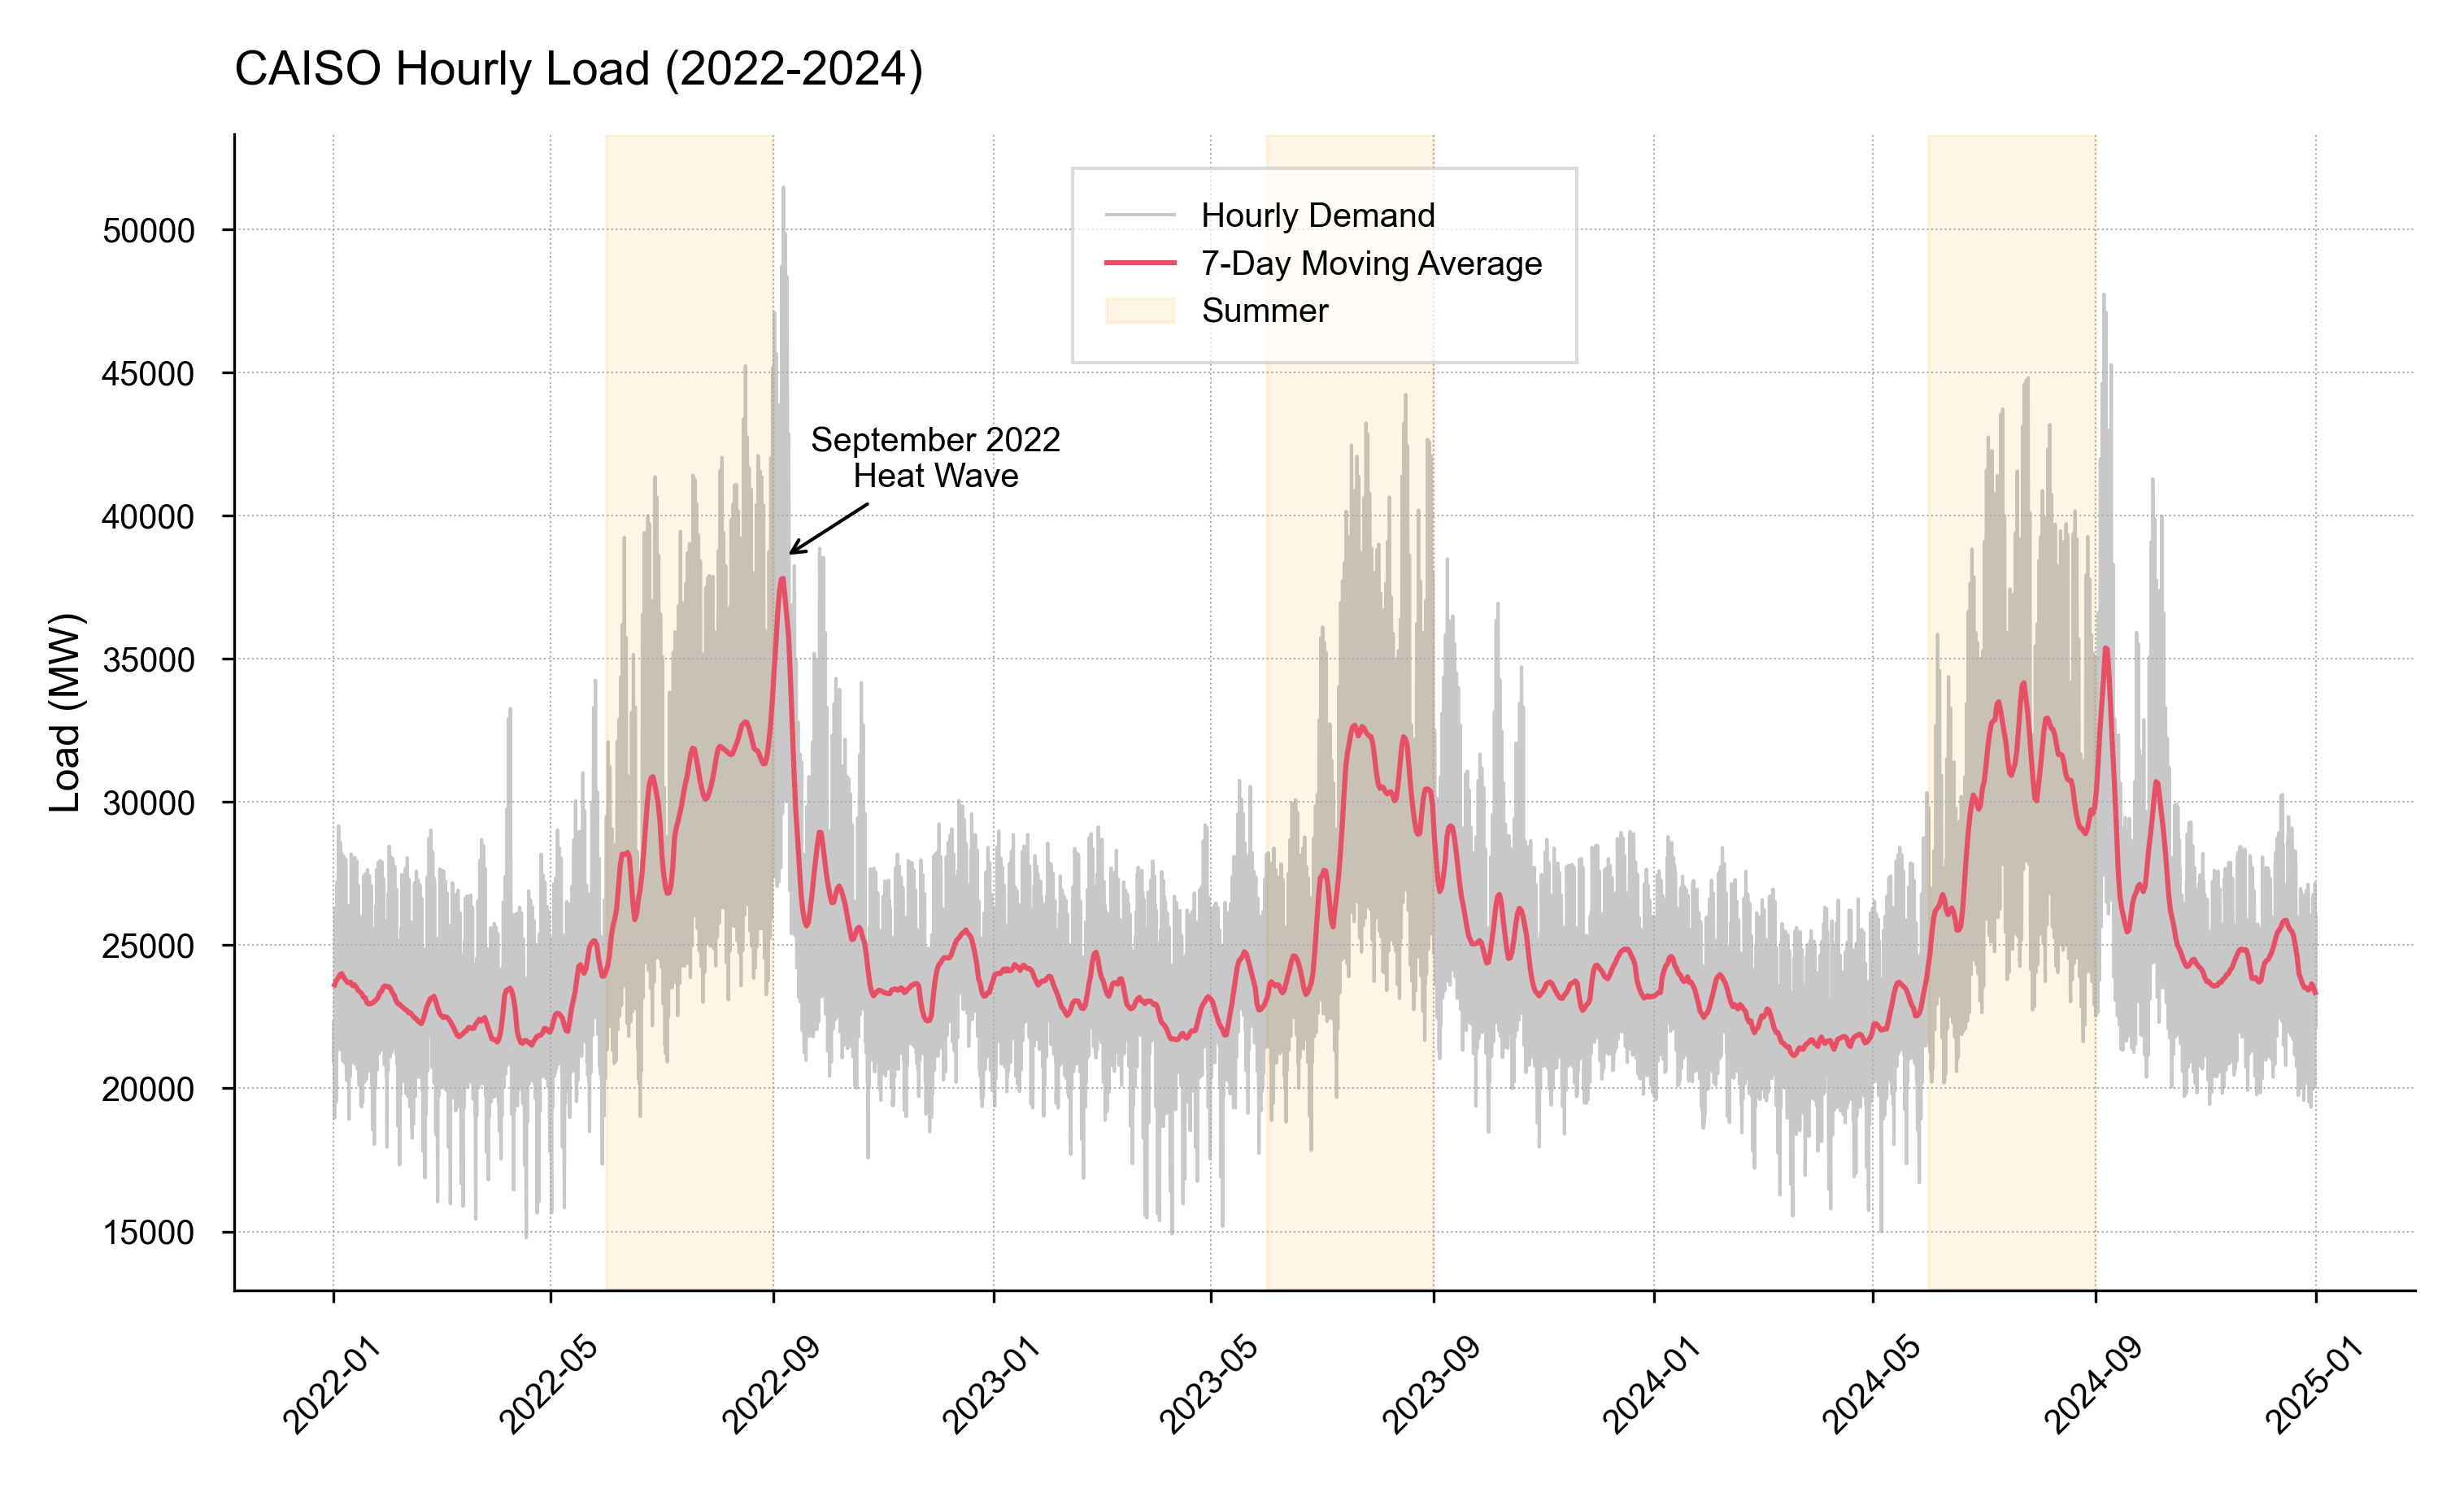

In [8]:
# caclculate centered moving average
df_daily["load_ma"] = df_daily["load"].rolling(window=7, min_periods=1, center=True).mean()

# # join to original df
# detrended_df = df[["datetime", "date", "load"]].merge(df_daily[["date", "load_ma"]], on="date", how="left")
# detrended_df["load_detrended"] = detrended_df["load"] - detrended_df["load_ma"]

# plot line line chart
plt.figure(figsize=(10, 6))

plt.plot(df["datetime"], df["load"], alpha=0.3, label="Hourly Demand", linewidth=1, zorder=1)
plt.plot(df_daily["datetime"], df_daily["load_ma"], label="7-Day Moving Average", linewidth=1.5, zorder=2)

# highlight summers
plt.axvspan(pd.to_datetime("2022-06-01"), pd.to_datetime("2022-09-01"), color="orange", alpha=0.1, label="Summer", zorder=0)
plt.axvspan(pd.to_datetime("2023-06-01"), pd.to_datetime("2023-09-01"), color="orange", alpha=0.1, zorder=0)
plt.axvspan(pd.to_datetime("2024-06-01"), pd.to_datetime("2024-09-01"), color="orange", alpha=0.1, zorder=0)

# annotate spike in september 2022 with centered text
plt.annotate("September 2022\nHeat Wave",
             xy=(pd.to_datetime("2022-09-06"), 38500),
             xytext=(pd.to_datetime("2022-11-30"), 41000),
             arrowprops=dict(arrowstyle="->", color="black"),
             fontsize=10,
            ha="center",
)

plt.title("CAISO Hourly Load (2022-2024)", loc="left", fontweight="regular")
# plt.xlabel("Hour")
plt.ylabel("Load (MW)")
plt.xticks(rotation=45)
plt.legend(loc="upper center", frameon=True, fontsize=10, framealpha=0.7, borderpad=1, fancybox=False)

plt.show()


# # plot line line chart
# plt.figure(figsize=(10, 6))

# plt.plot(detrended_df["datetime"], detrended_df["CAISO_detrended"], alpha=0.3, label="Hourly Demand", linewidth=1)
# # plt.plot(df_daily["datetime"], df_daily["CAISO_MA"], label="7-Day Moving Average", linewidth=1.5)

# plt.title("CAISO Hourly Load, Detrended (2022-2023)", loc="left", fontweight="regular")
# # plt.xlabel("Hour")
# plt.ylabel("Load (MW)")
# plt.xticks(rotation=45)
# plt.legend(loc="upper left", frameon=True, fontsize=10, framealpha=0.7, borderpad=1, fancybox=False)

# plt.show()

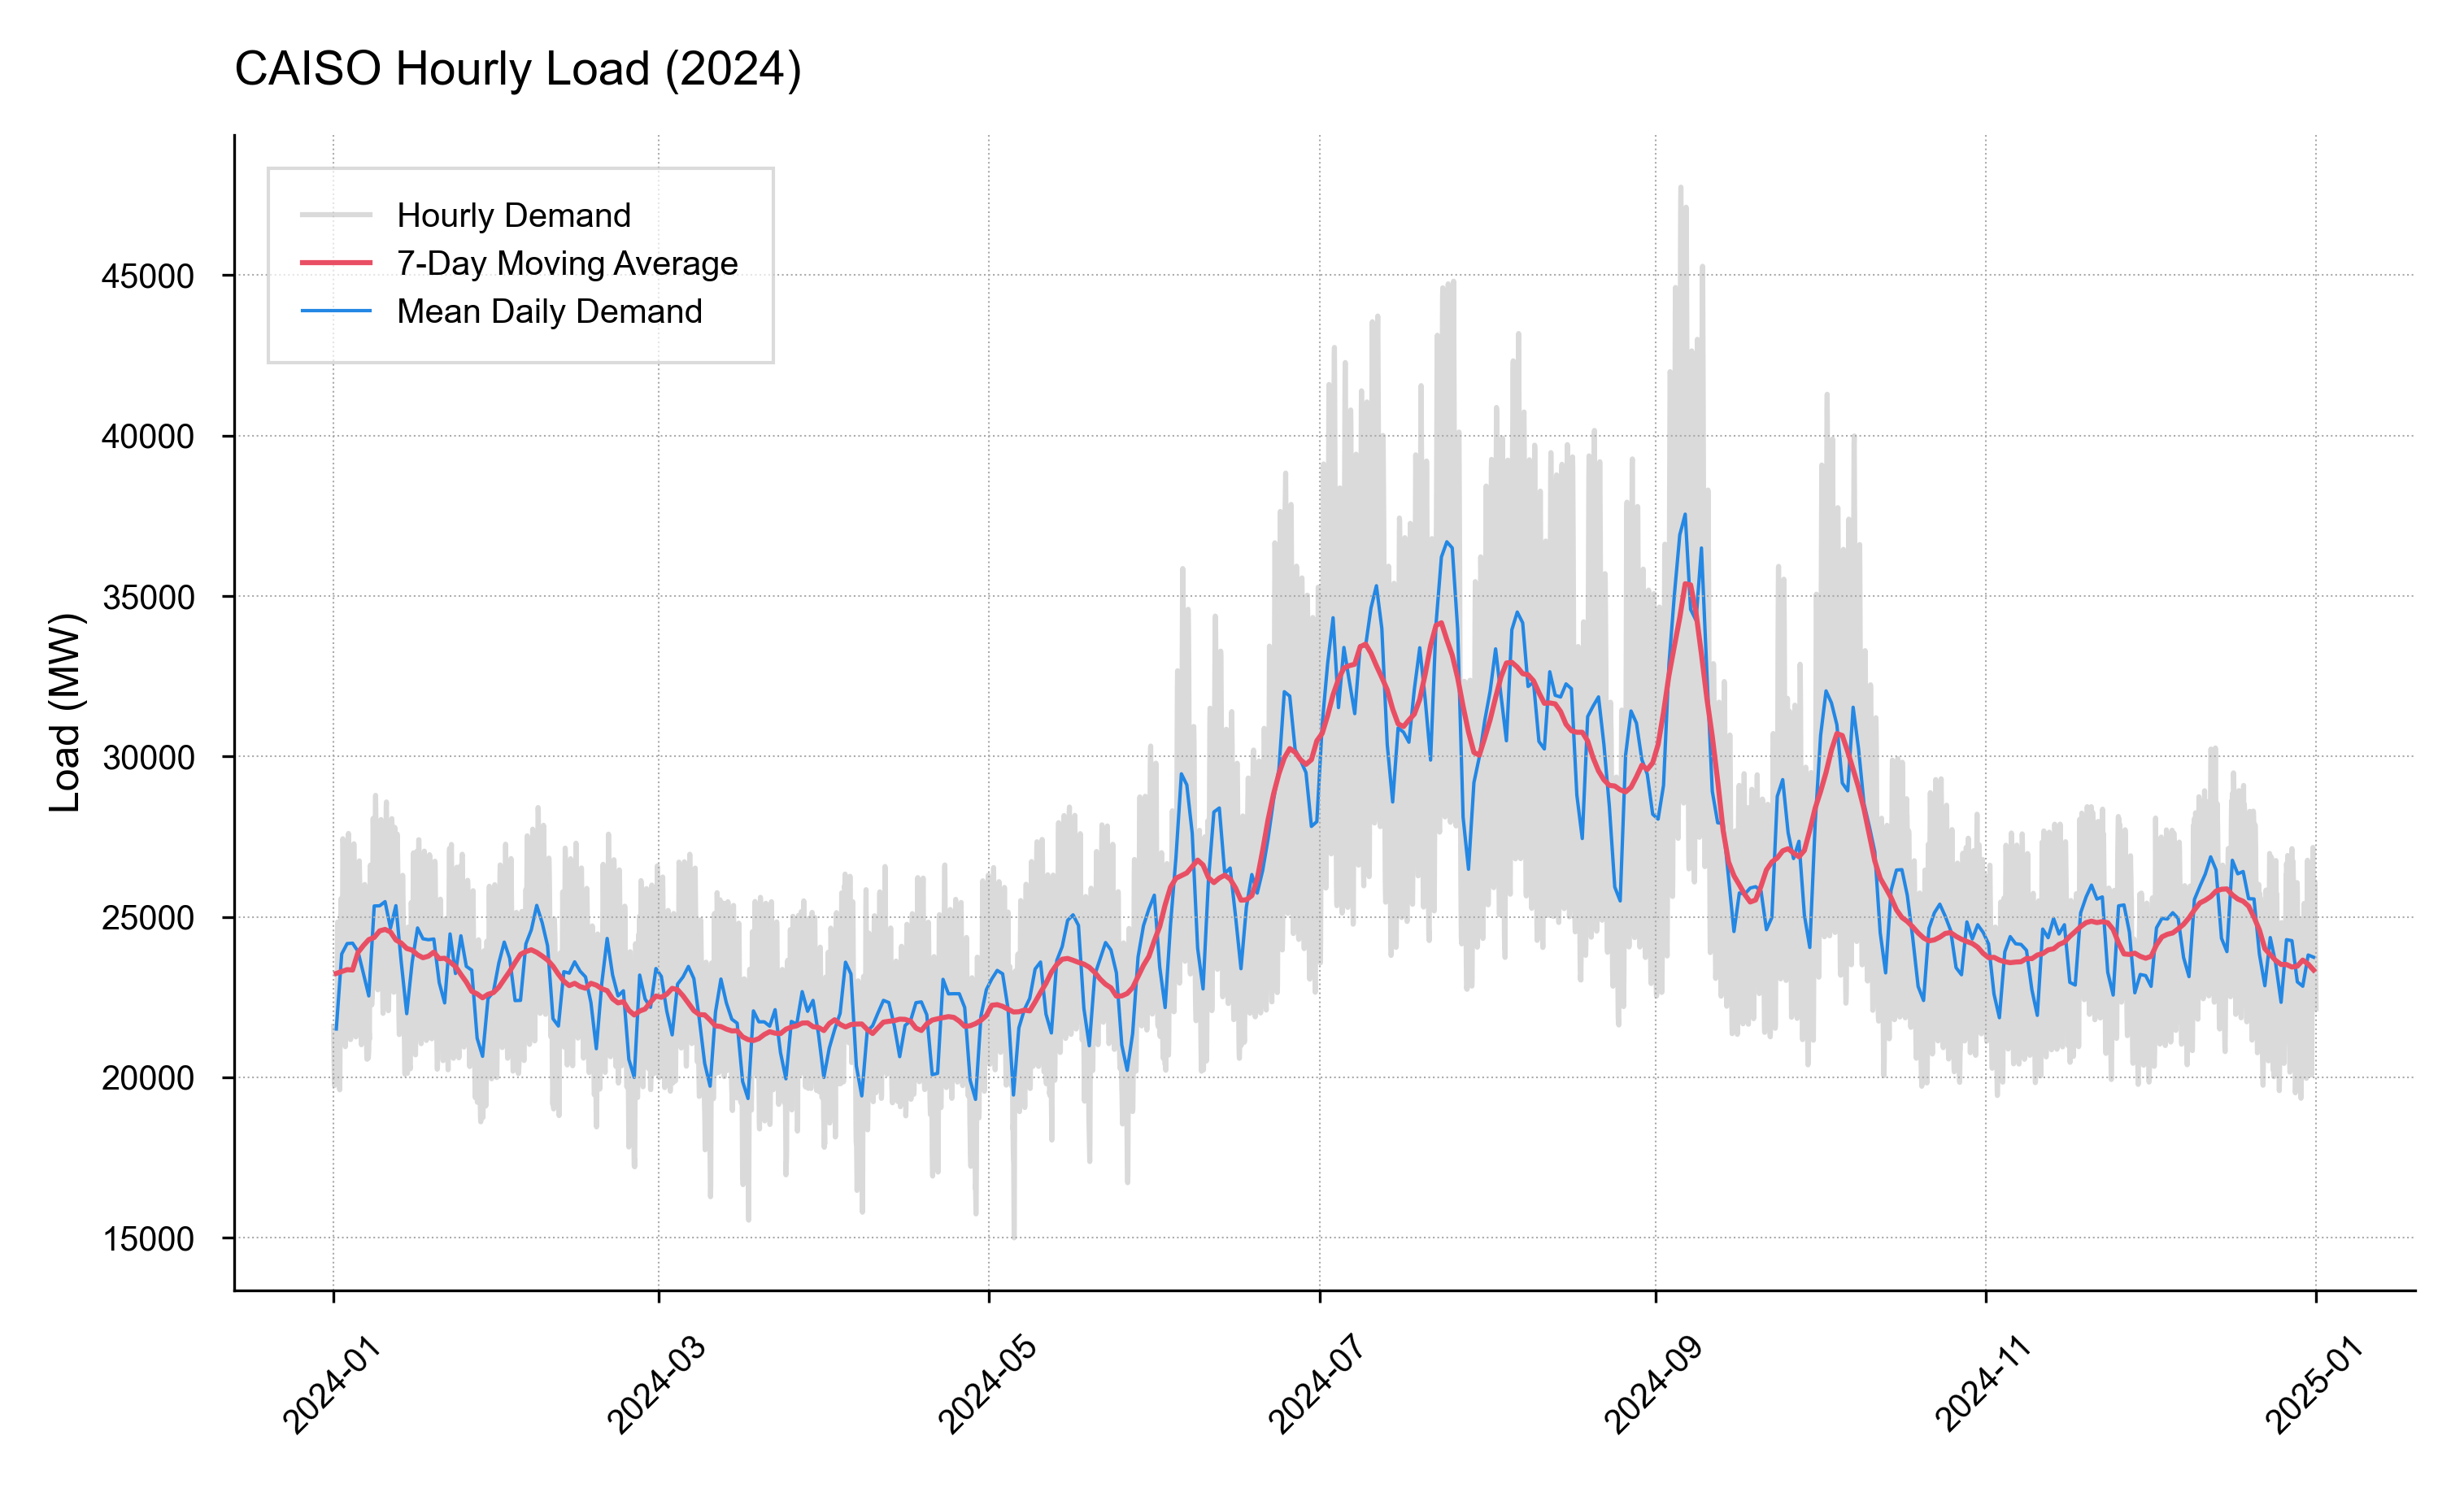

In [9]:
df_2024_daily = df_daily[df_daily["datetime"].dt.year == 2024].copy()

# plot line line chart
plt.figure(figsize=(10, 6))

plt.plot(df_2024["datetime"], df_2024["load"], alpha=0.2, label="Hourly Demand", linewidth=1.5, zorder=0)
plt.plot(df_2024_daily["datetime"], df_2024_daily["load_ma"], label="7-Day Moving Average", linewidth=1.5, zorder=2)
plt.plot(df_2024_daily["datetime"], df_2024_daily["load"], label="Mean Daily Demand", linewidth=1, color="#2387e4", linestyle="solid", zorder=1)

plt.title("CAISO Hourly Load (2024)", loc="left", fontweight="regular")
# plt.xlabel("Hour")
plt.ylabel("Load (MW)")
plt.xticks(rotation=45)
plt.legend(loc="upper left", frameon=True, fontsize=10, framealpha=0.7, borderpad=1, fancybox=False)

plt.show()

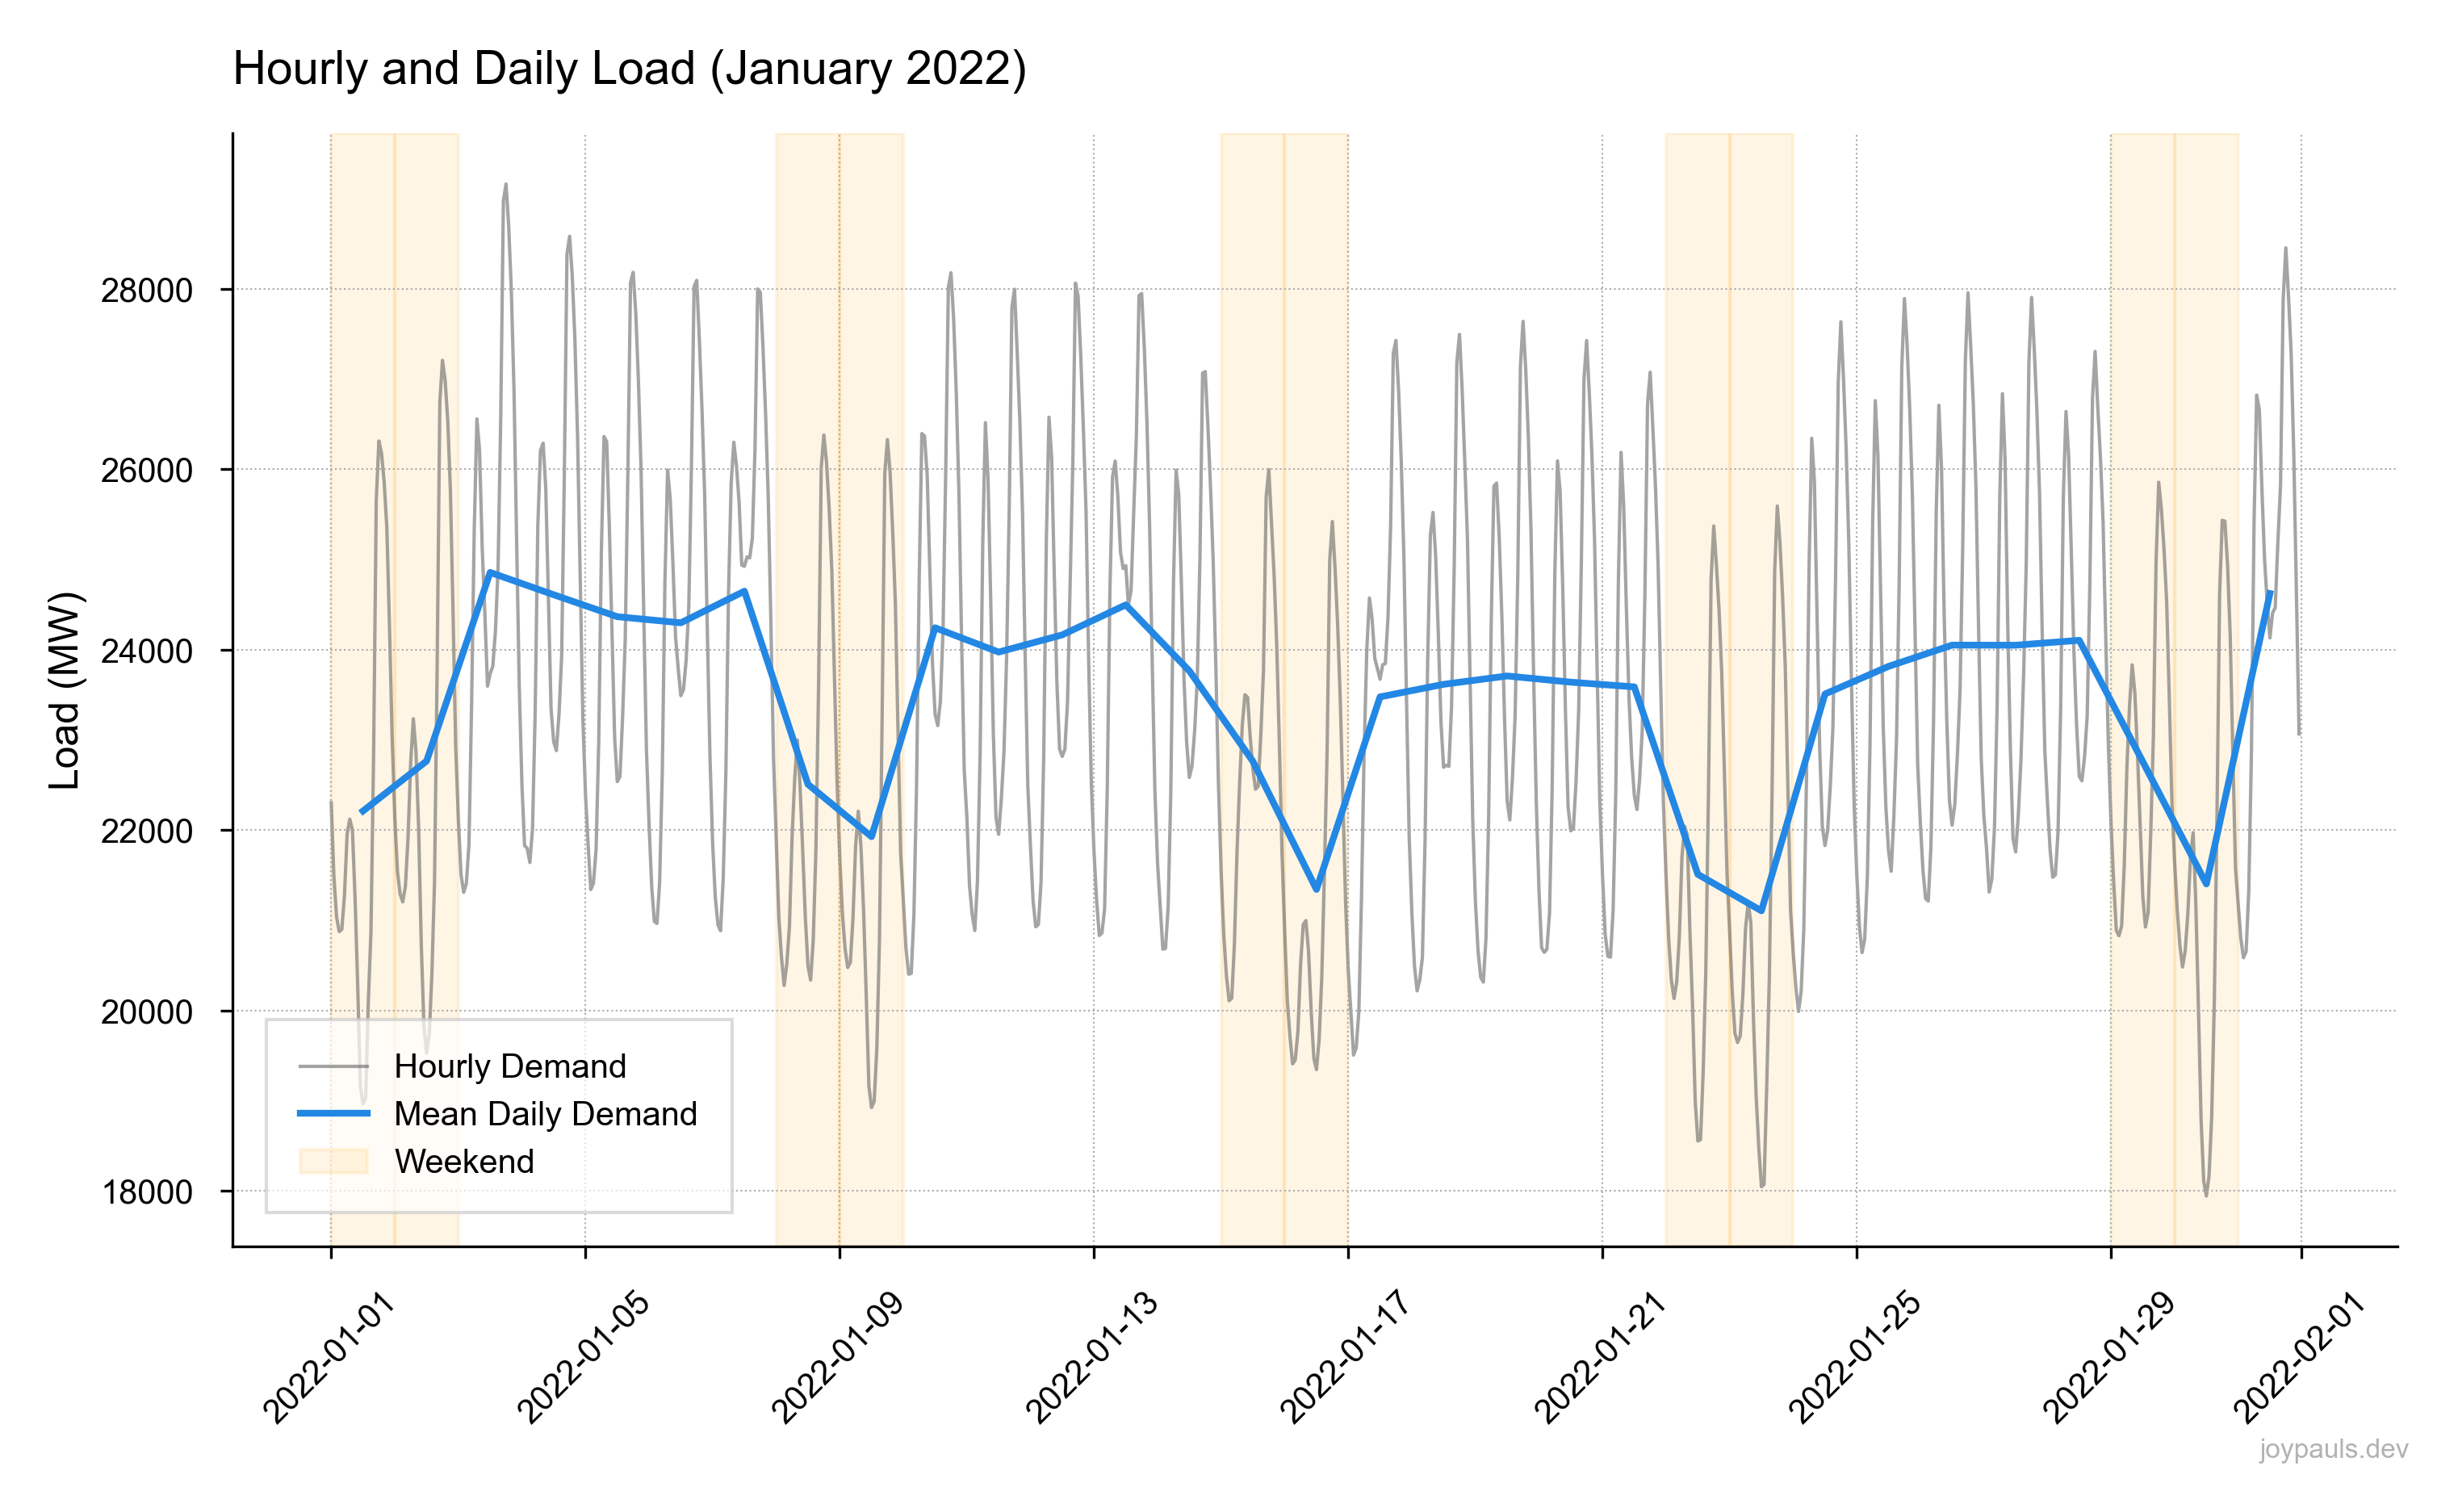

In [ ]:
df_2022_daily = df_daily[df_daily["datetime"].dt.year == 2022].copy()
df_2022_jan_daily = df_2022_daily[df_2022_daily["datetime"].dt.month == 1].copy()
df_2022_jan = df_2022[df_2022["datetime"].dt.month == 1].copy()

# plot line line chart
plt.figure(figsize=(10, 6))

plt.plot(df_2022_jan["datetime"], df_2022_jan["load"], alpha=0.5, label="Hourly Demand", linewidth=1, zorder=1)
plt.plot(df_2022_jan_daily["datetime"], df_2022_jan_daily["load"], label="Mean Daily Demand", linewidth=2, color="#2387e4", linestyle="solid", zorder=2)

# highlight weekends
for i in range(len(df_2022_jan_daily)):
    if df_2022_jan_daily["dow"].iloc[i] > 4:  # Saturday or Sunday
        plt.axvspan(df_2022_jan_daily["datetime"].iloc[i] - pd.Timedelta(hours=12),
                    df_2022_jan_daily["datetime"].iloc[i] + pd.Timedelta(hours=12),
                    color="orange", alpha=0.1, label="Weekend" if i == 0 else "", zorder=0)

plt.title("Hourly and Daily Load (January 2022)", loc="left", fontweight="regular")
# plt.xlabel("Hour")
plt.ylabel("Load (MW)")
plt.xticks(rotation=45)
plt.legend(loc="lower left", frameon=True, fontsize=10, framealpha=0.7, borderpad=1, fancybox=False)

plt.gcf().text(0.99, 0.001, "joypauls.dev", ha="right", va="bottom", fontsize=8, color="gray", alpha=0.6)

plt.show()

In [11]:
# # plot line line chart
# plt.figure(figsize=(10, 6))

# plt.scatter(df["hour"], df["CAISO"], alpha=0.2)
# plt.title("Hourly Load Demand")
# plt.xlabel("Hour")
# plt.ylabel("Load (MW)")

# plt.show()


In [12]:
# group by hour calculate mean load
df_2022_hour_avg = df_2022.groupby(["hour"])["CAISO"].mean().reset_index()

df_2022_hour_avg

KeyError: 'Column not found: CAISO'

In [34]:
# group by hour calculate mean load
df_2023_hour_avg = df_2023.groupby(["hour"])["CAISO"].mean().reset_index()

df_2023_hour_avg

,hour,CAISO
0,0,23691.417435
1,1,22870.799781
2,2,22295.466996
3,3,21958.178216
4,4,21971.244728
5,5,22692.145246
6,6,23926.540285
7,7,24883.800687
8,8,25265.940195
9,9,24927.074944


In [32]:
# group by hour and month and calculate mean load
df_2022_month_avg = df_2022.groupby(["month", "hour"])["CAISO"].mean().reset_index()

df_2022_month_avg

,month,hour,CAISO
0,1,0,21663.323548
1,1,1,21061.476452
2,1,2,20719.545806
3,1,3,20674.869355
4,1,4,21045.448387
...,...,...,...
283,12,19,27339.580968
284,12,20,26802.702581
285,12,21,26080.440968
286,12,22,24783.861935


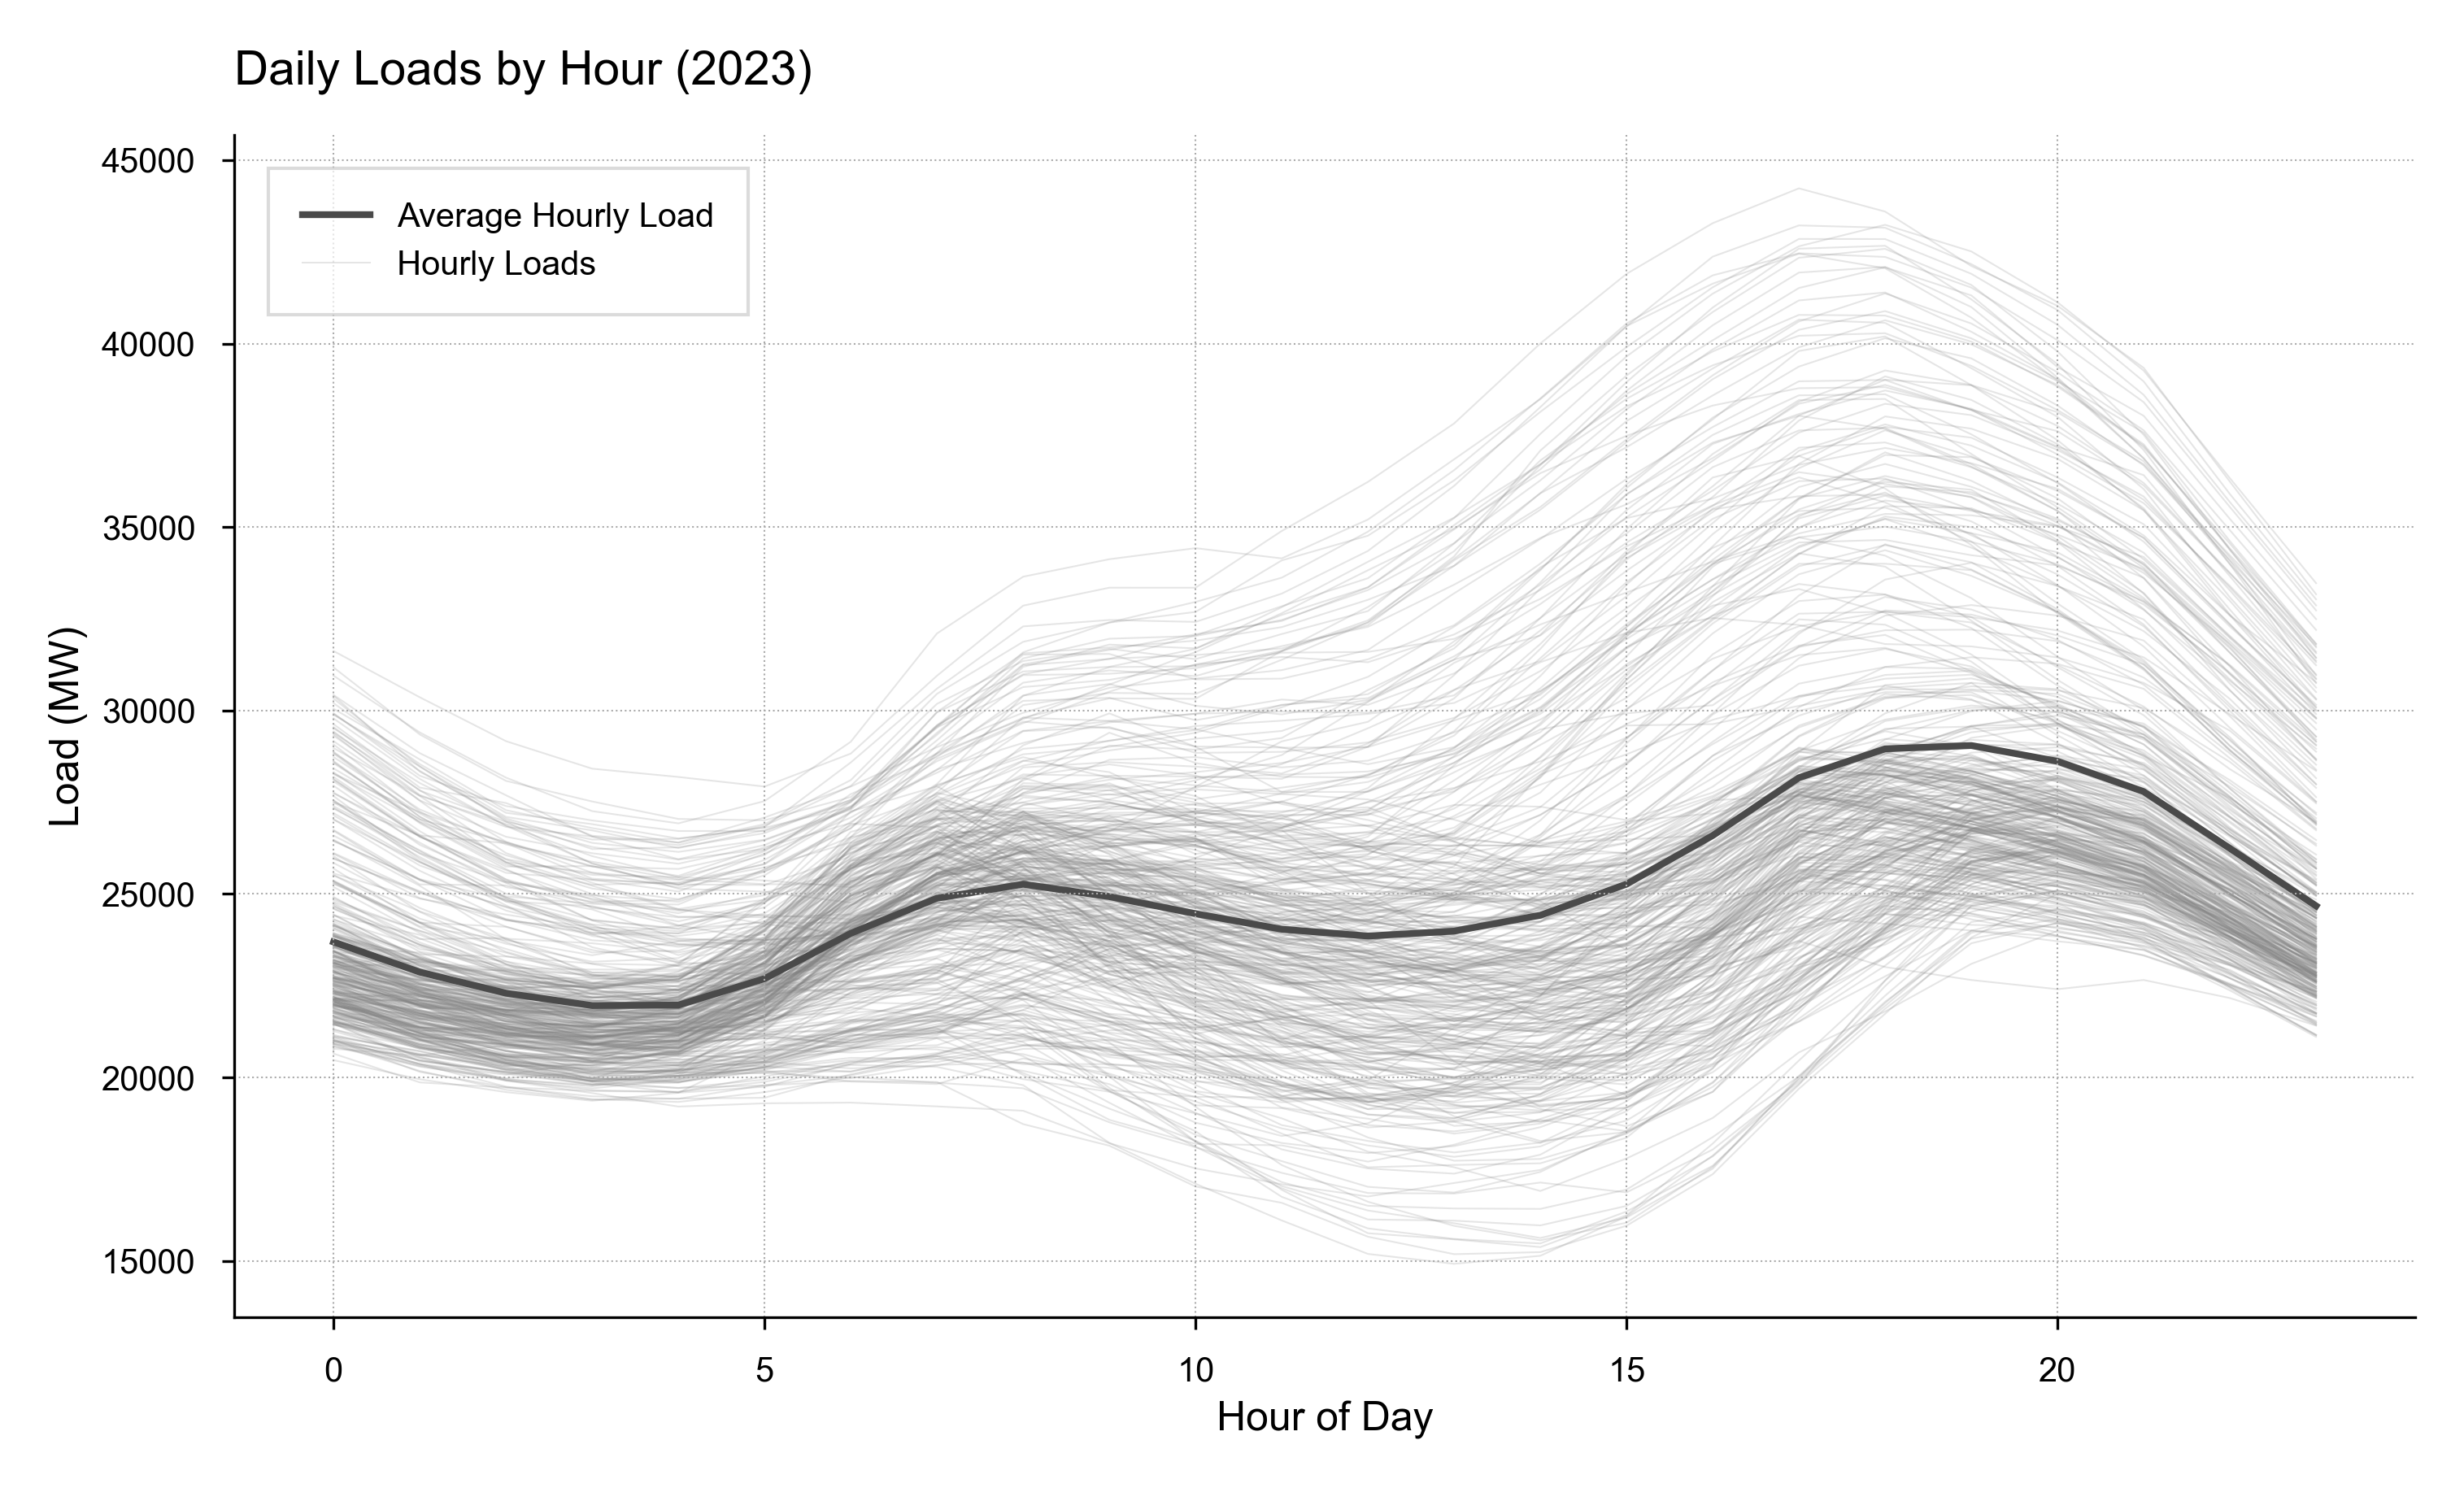

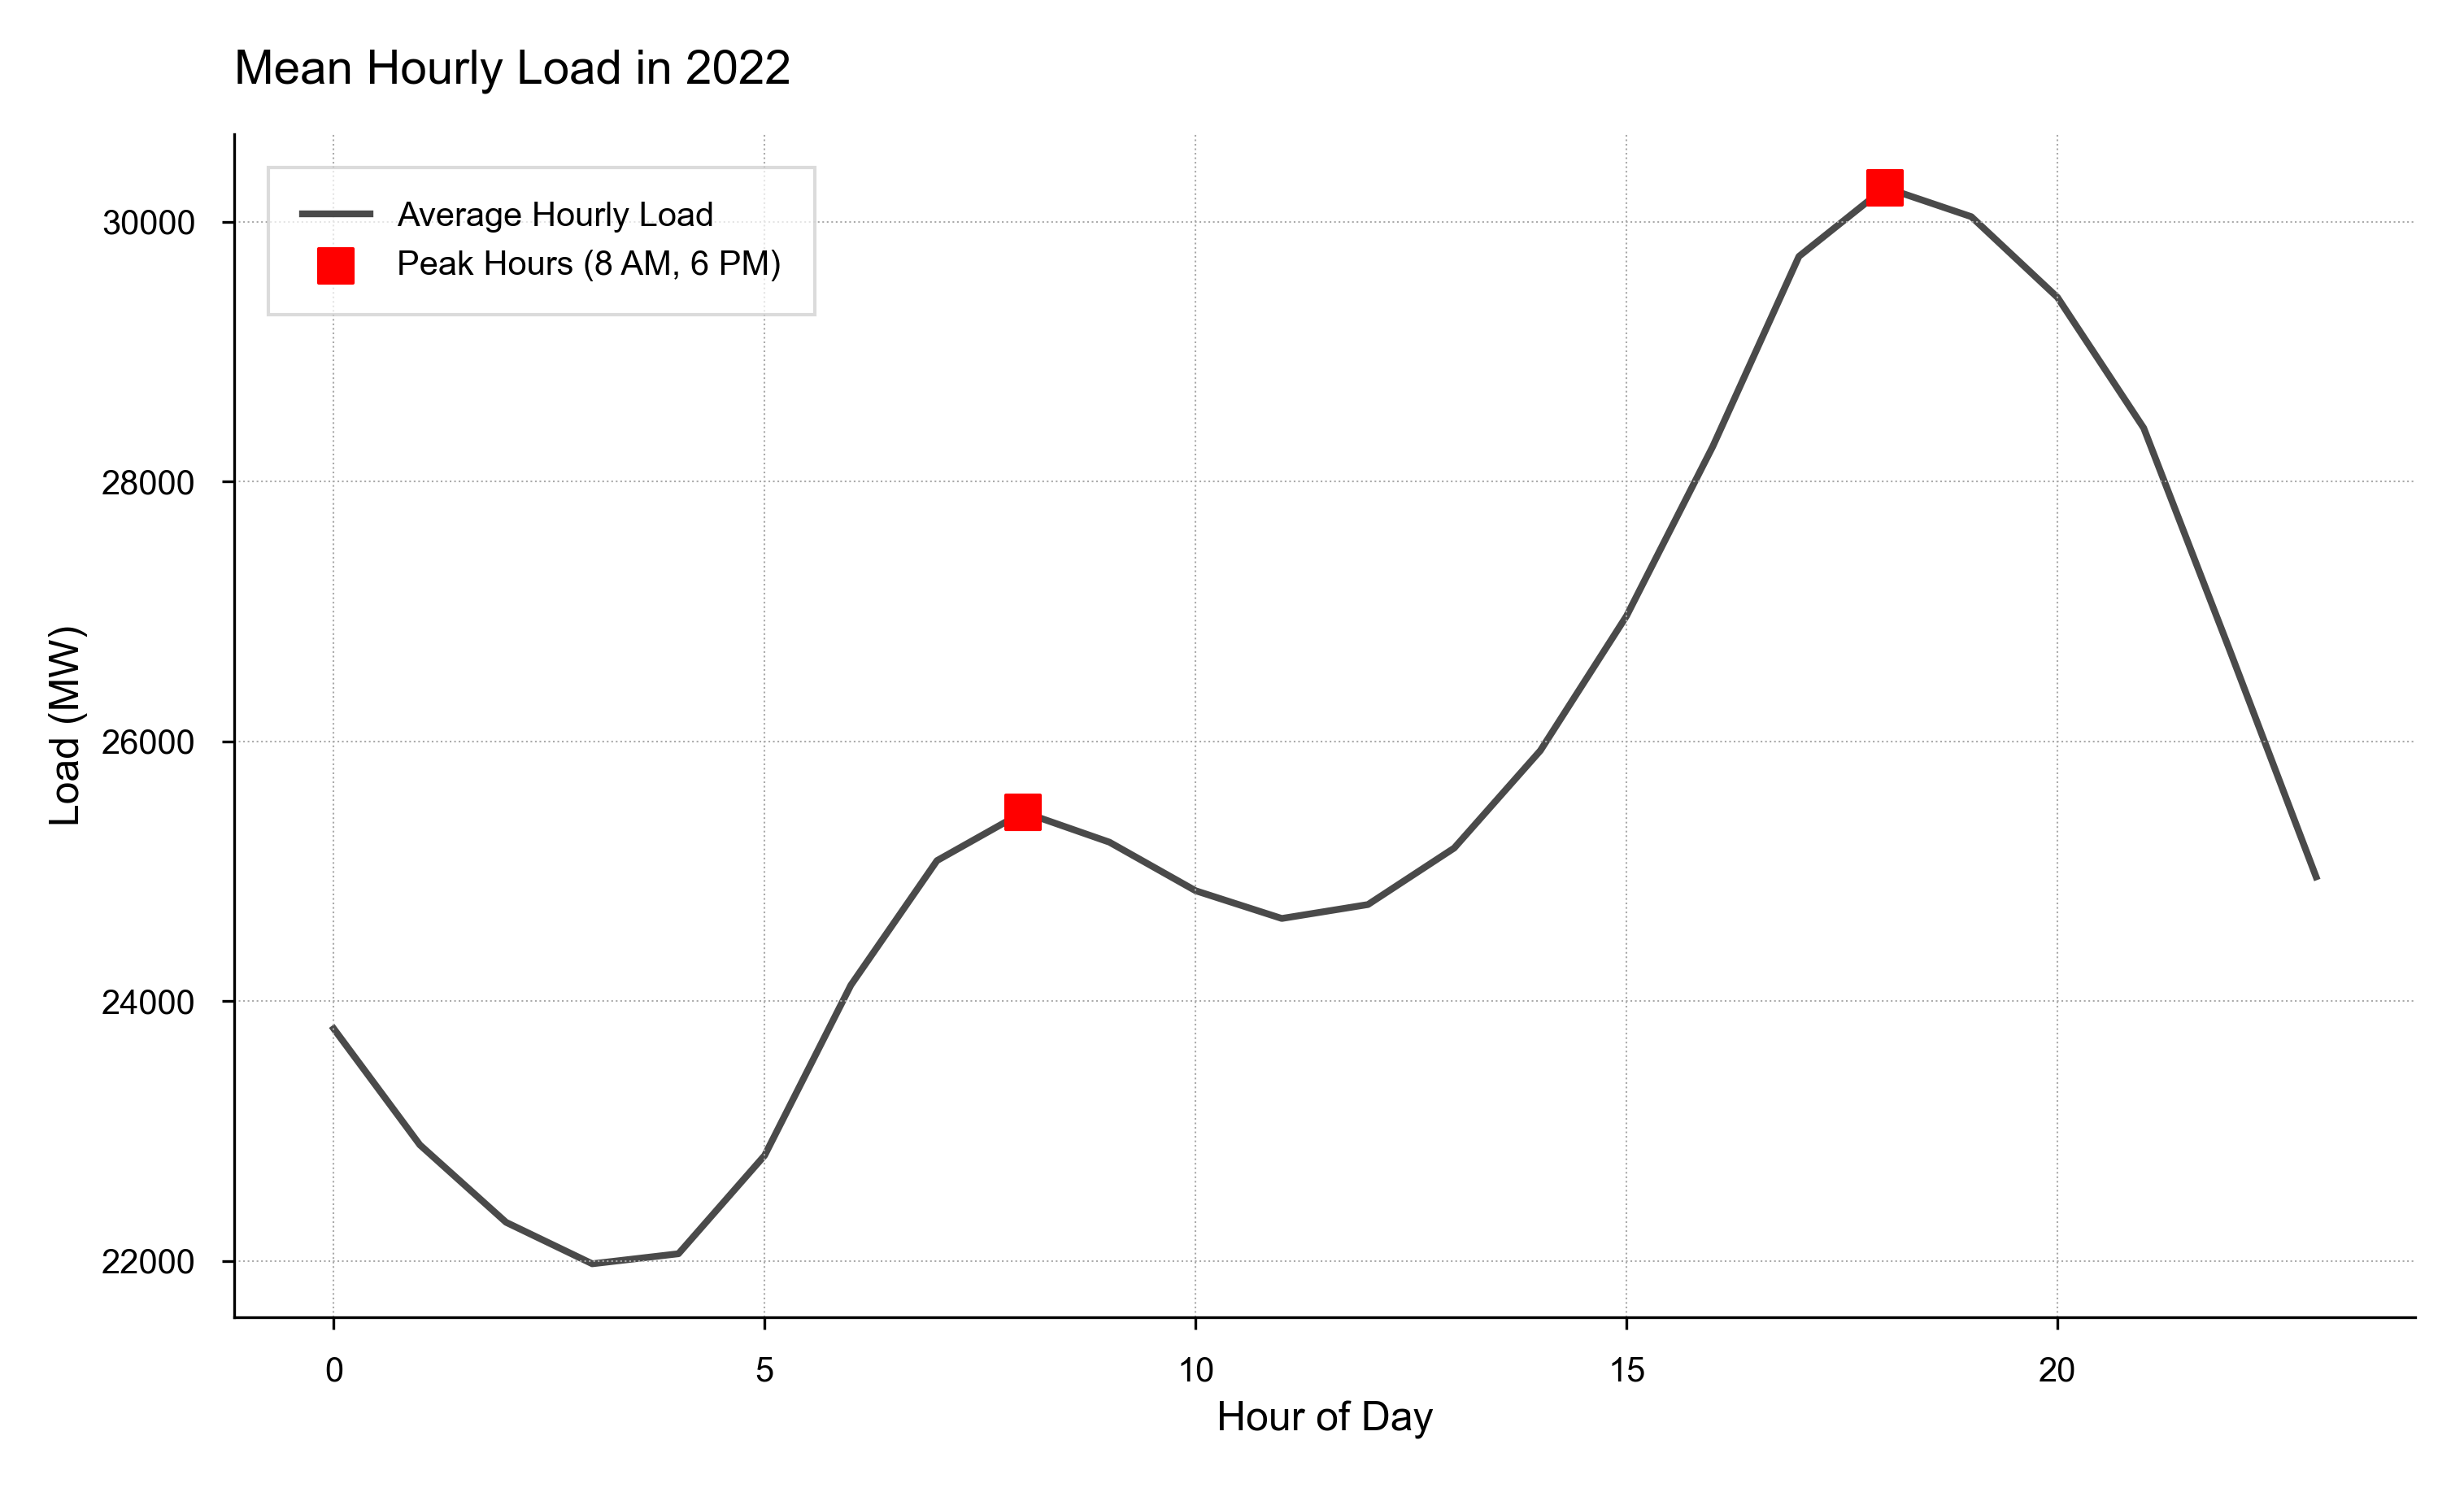

In [35]:
# line plot of average load by hour
plt.figure(figsize=(10, 6))
# plt.scatter(df["hour"], df["CAISO"], alpha=0.2, zorder = 0)

plt.plot(df_2023_hour_avg["hour"], df_2023_hour_avg["CAISO"], label="Average Hourly Load", linewidth=2, zorder = 1)

# plot all other days 
for month in df_2023["date"].unique():
    month_data = df_2023[df_2023["date"] == month]
    plt.plot(month_data["hour"], month_data["CAISO"], alpha=0.2, color="gray", linewidth=0.5, zorder=0, label="Hourly Loads" if month == df_2023["date"].unique()[0] else "")

plt.title("Daily Loads by Hour (2023)", loc="left", fontweight="regular")
plt.xlabel("Hour of Day")
plt.ylabel("Load (MW)")
plt.legend(loc="upper left", frameon=True, fontsize=10, framealpha=0.7, borderpad=1, fancybox=False)
plt.show()

# # line plot of average load by hour
# plt.figure(figsize=(10, 6))
# # plt.scatter(df["hour"], df["CAISO"], alpha=0.2, zorder = 0)
# plt.plot(df_2023_hour_avg["hour"], df_2023_hour_avg["CAISO"], label="Average Hourly Load", marker="s", linewidth=2, zorder = 1, markersize=7)
# plt.scatter([8, 18], df_2023_hour_avg[df_2023_hour_avg["hour"].isin([8, 18])]["CAISO"], color="red", marker="s", s=100, alpha=1.0, label="Peak Hours (8 AM, 6 PM)", zorder = 2)
# plt.title("Average Hourly Load in 2022")
# plt.xlabel("Hour of Day")
# plt.ylabel("Load (MW)")
# plt.legend()
# plt.show()

# line plot of average load by hour
plt.figure(figsize=(10, 6))
# plt.scatter(df["hour"], df["CAISO"], alpha=0.2, zorder = 0)
plt.plot(df_2022_hour_avg["hour"], df_2022_hour_avg["CAISO"], label="Average Hourly Load", marker="o", linewidth=2, zorder = 1, markersize=0)
plt.scatter([8, 18], df_2022_hour_avg[df_2022_hour_avg["hour"].isin([8, 18])]["CAISO"], color="red", marker="s", s=100, alpha=1.0, label="Peak Hours (8 AM, 6 PM)", zorder = 2)

plt.title("Mean Hourly Load in 2022", loc="left", fontweight="regular")
plt.xlabel("Hour of Day")
plt.ylabel("Load (MW)")
plt.legend(loc="upper left", frameon=True, fontsize=10, framealpha=0.7, borderpad=1, fancybox=False)
plt.show()


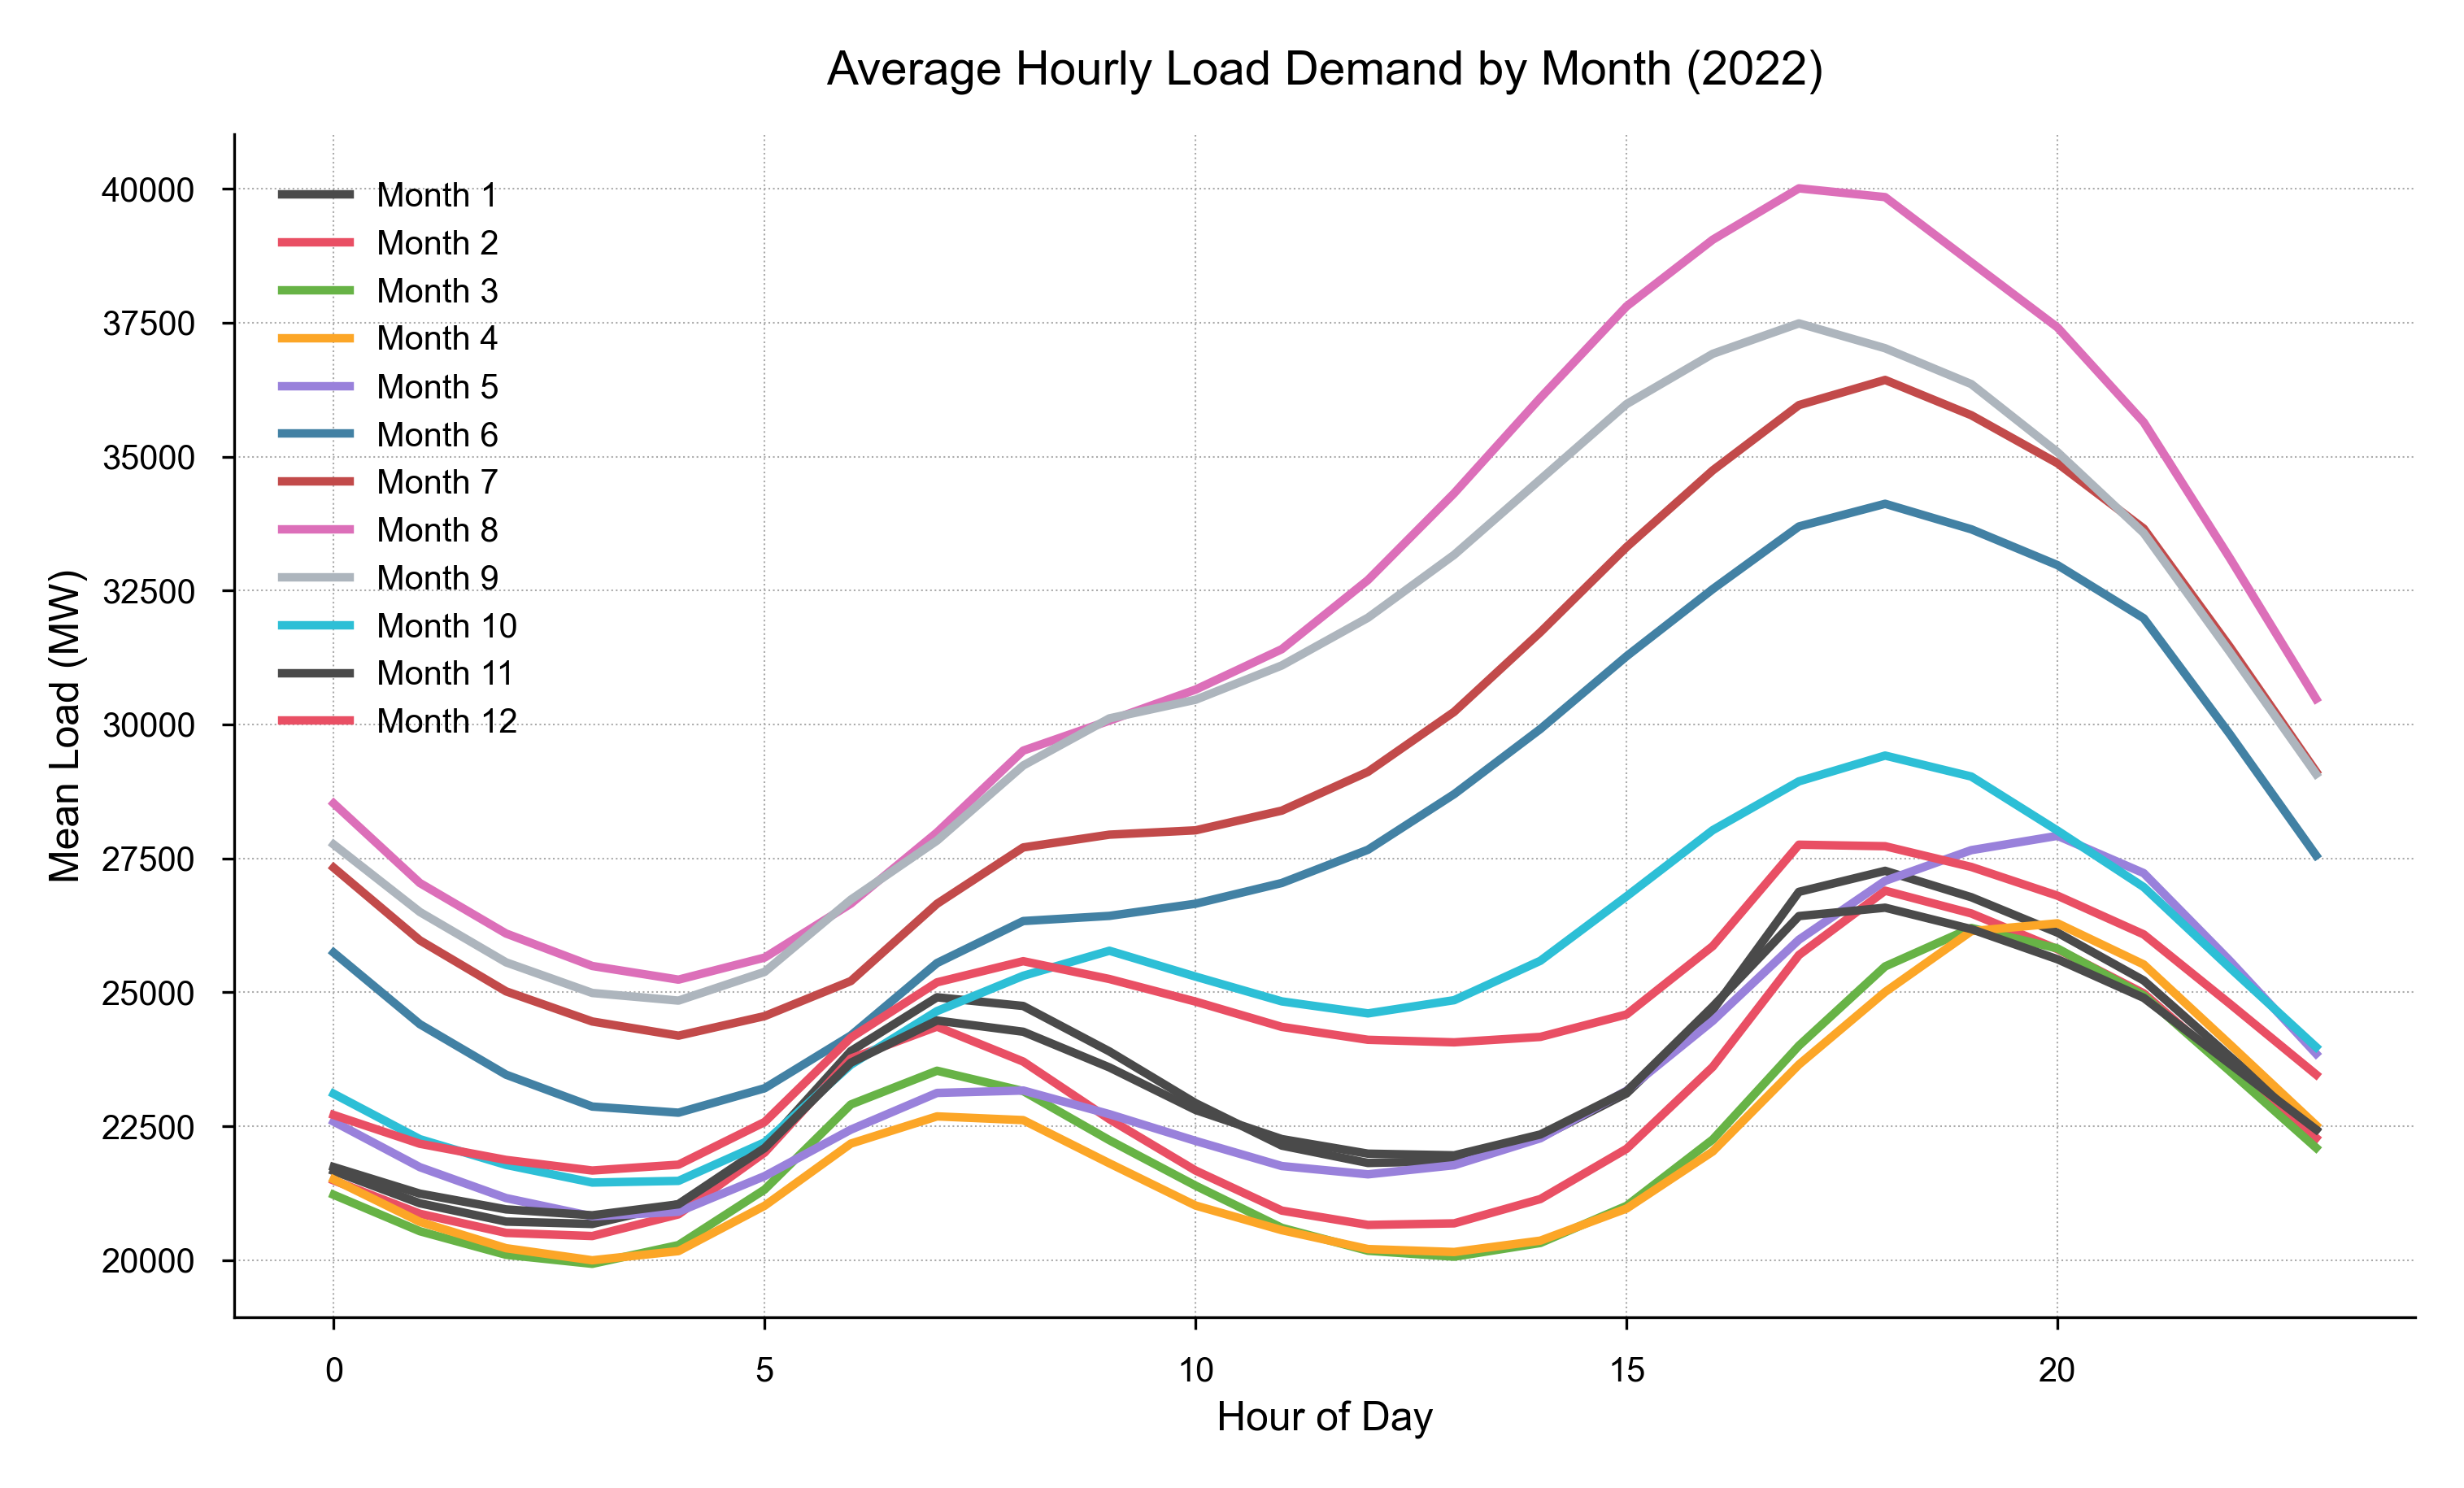

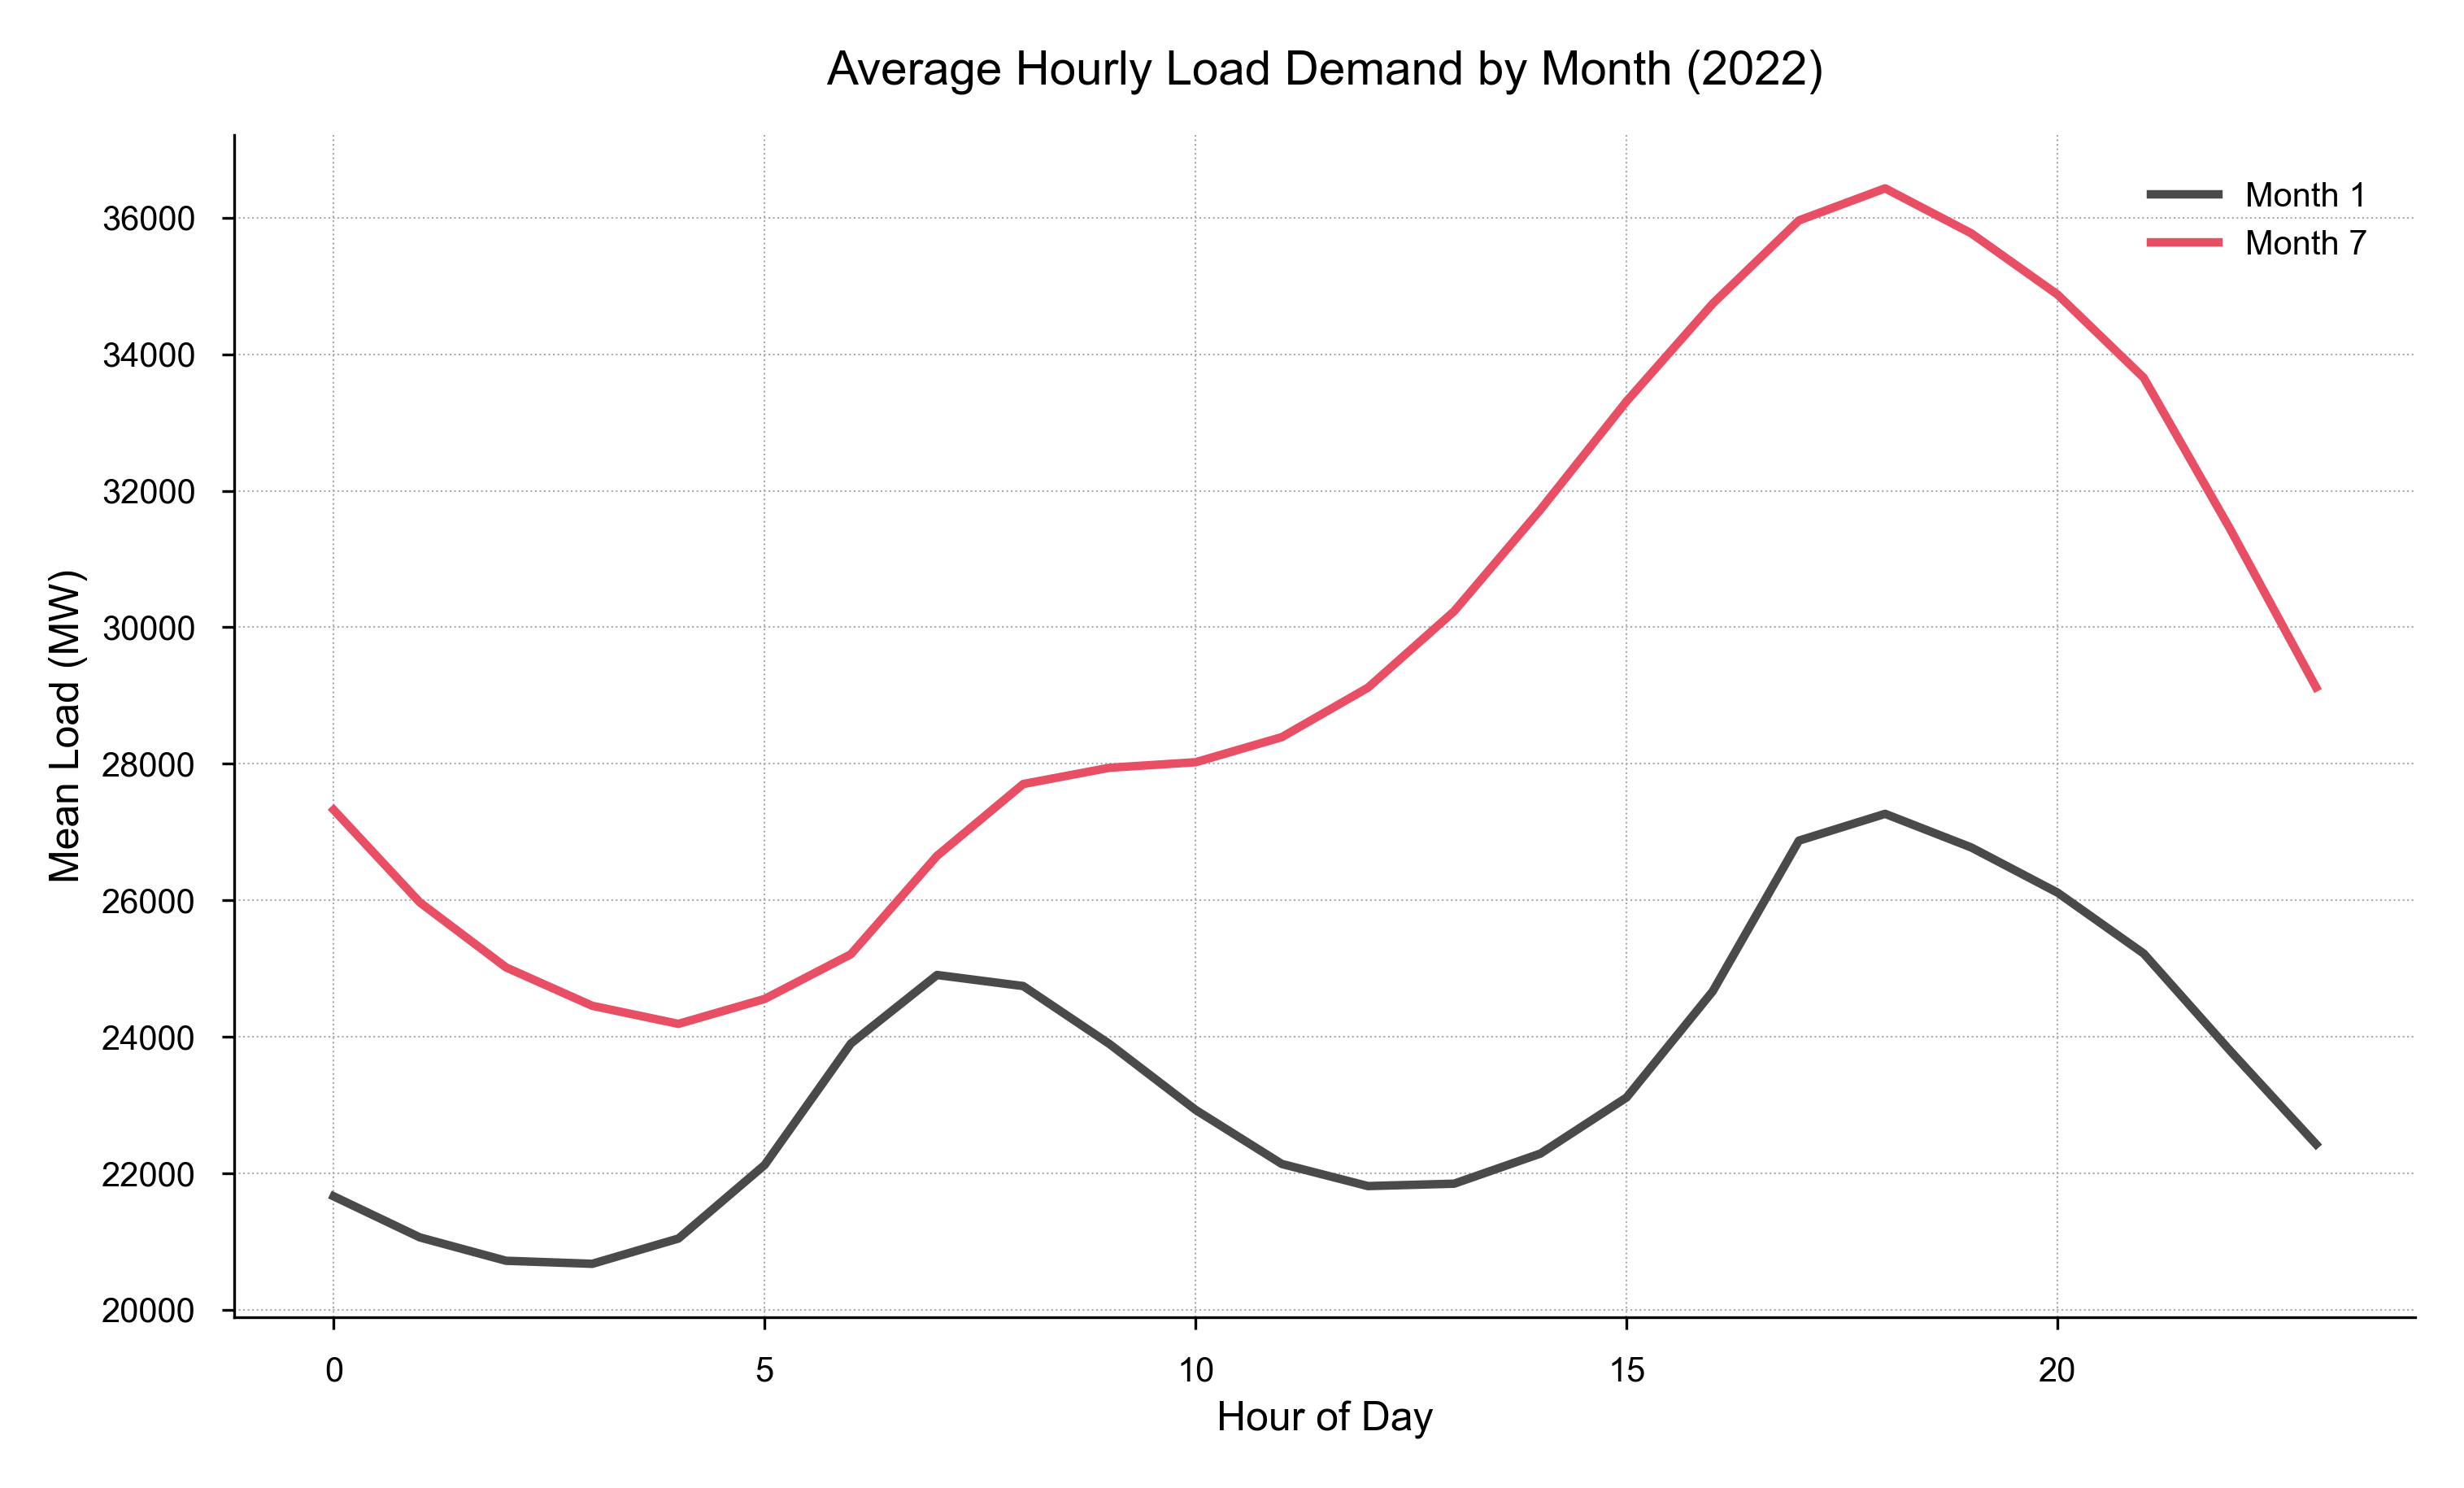

In [26]:
# plot line for each month
plt.figure(figsize=(10, 6))
for month in range(1, 13):
    monthly_data = df_2022_month_avg[df_2022_month_avg["month"] == month]
    plt.plot(monthly_data["hour"], monthly_data["CAISO"], label=f"Month {month}")
plt.title("Average Hourly Load Demand by Month (2022)")
plt.xlabel("Hour of Day")
plt.ylabel("Mean Load (MW)")
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
for month in [1, 7]:
    monthly_data = df_2022_month_avg[df_2022_month_avg["month"] == month]
    plt.plot(monthly_data["hour"], monthly_data["CAISO"], label=f"Month {month}")
plt.title("Average Hourly Load Demand by Month (2022)")
plt.xlabel("Hour of Day")
plt.ylabel("Mean Load (MW)")
plt.legend()
plt.show()

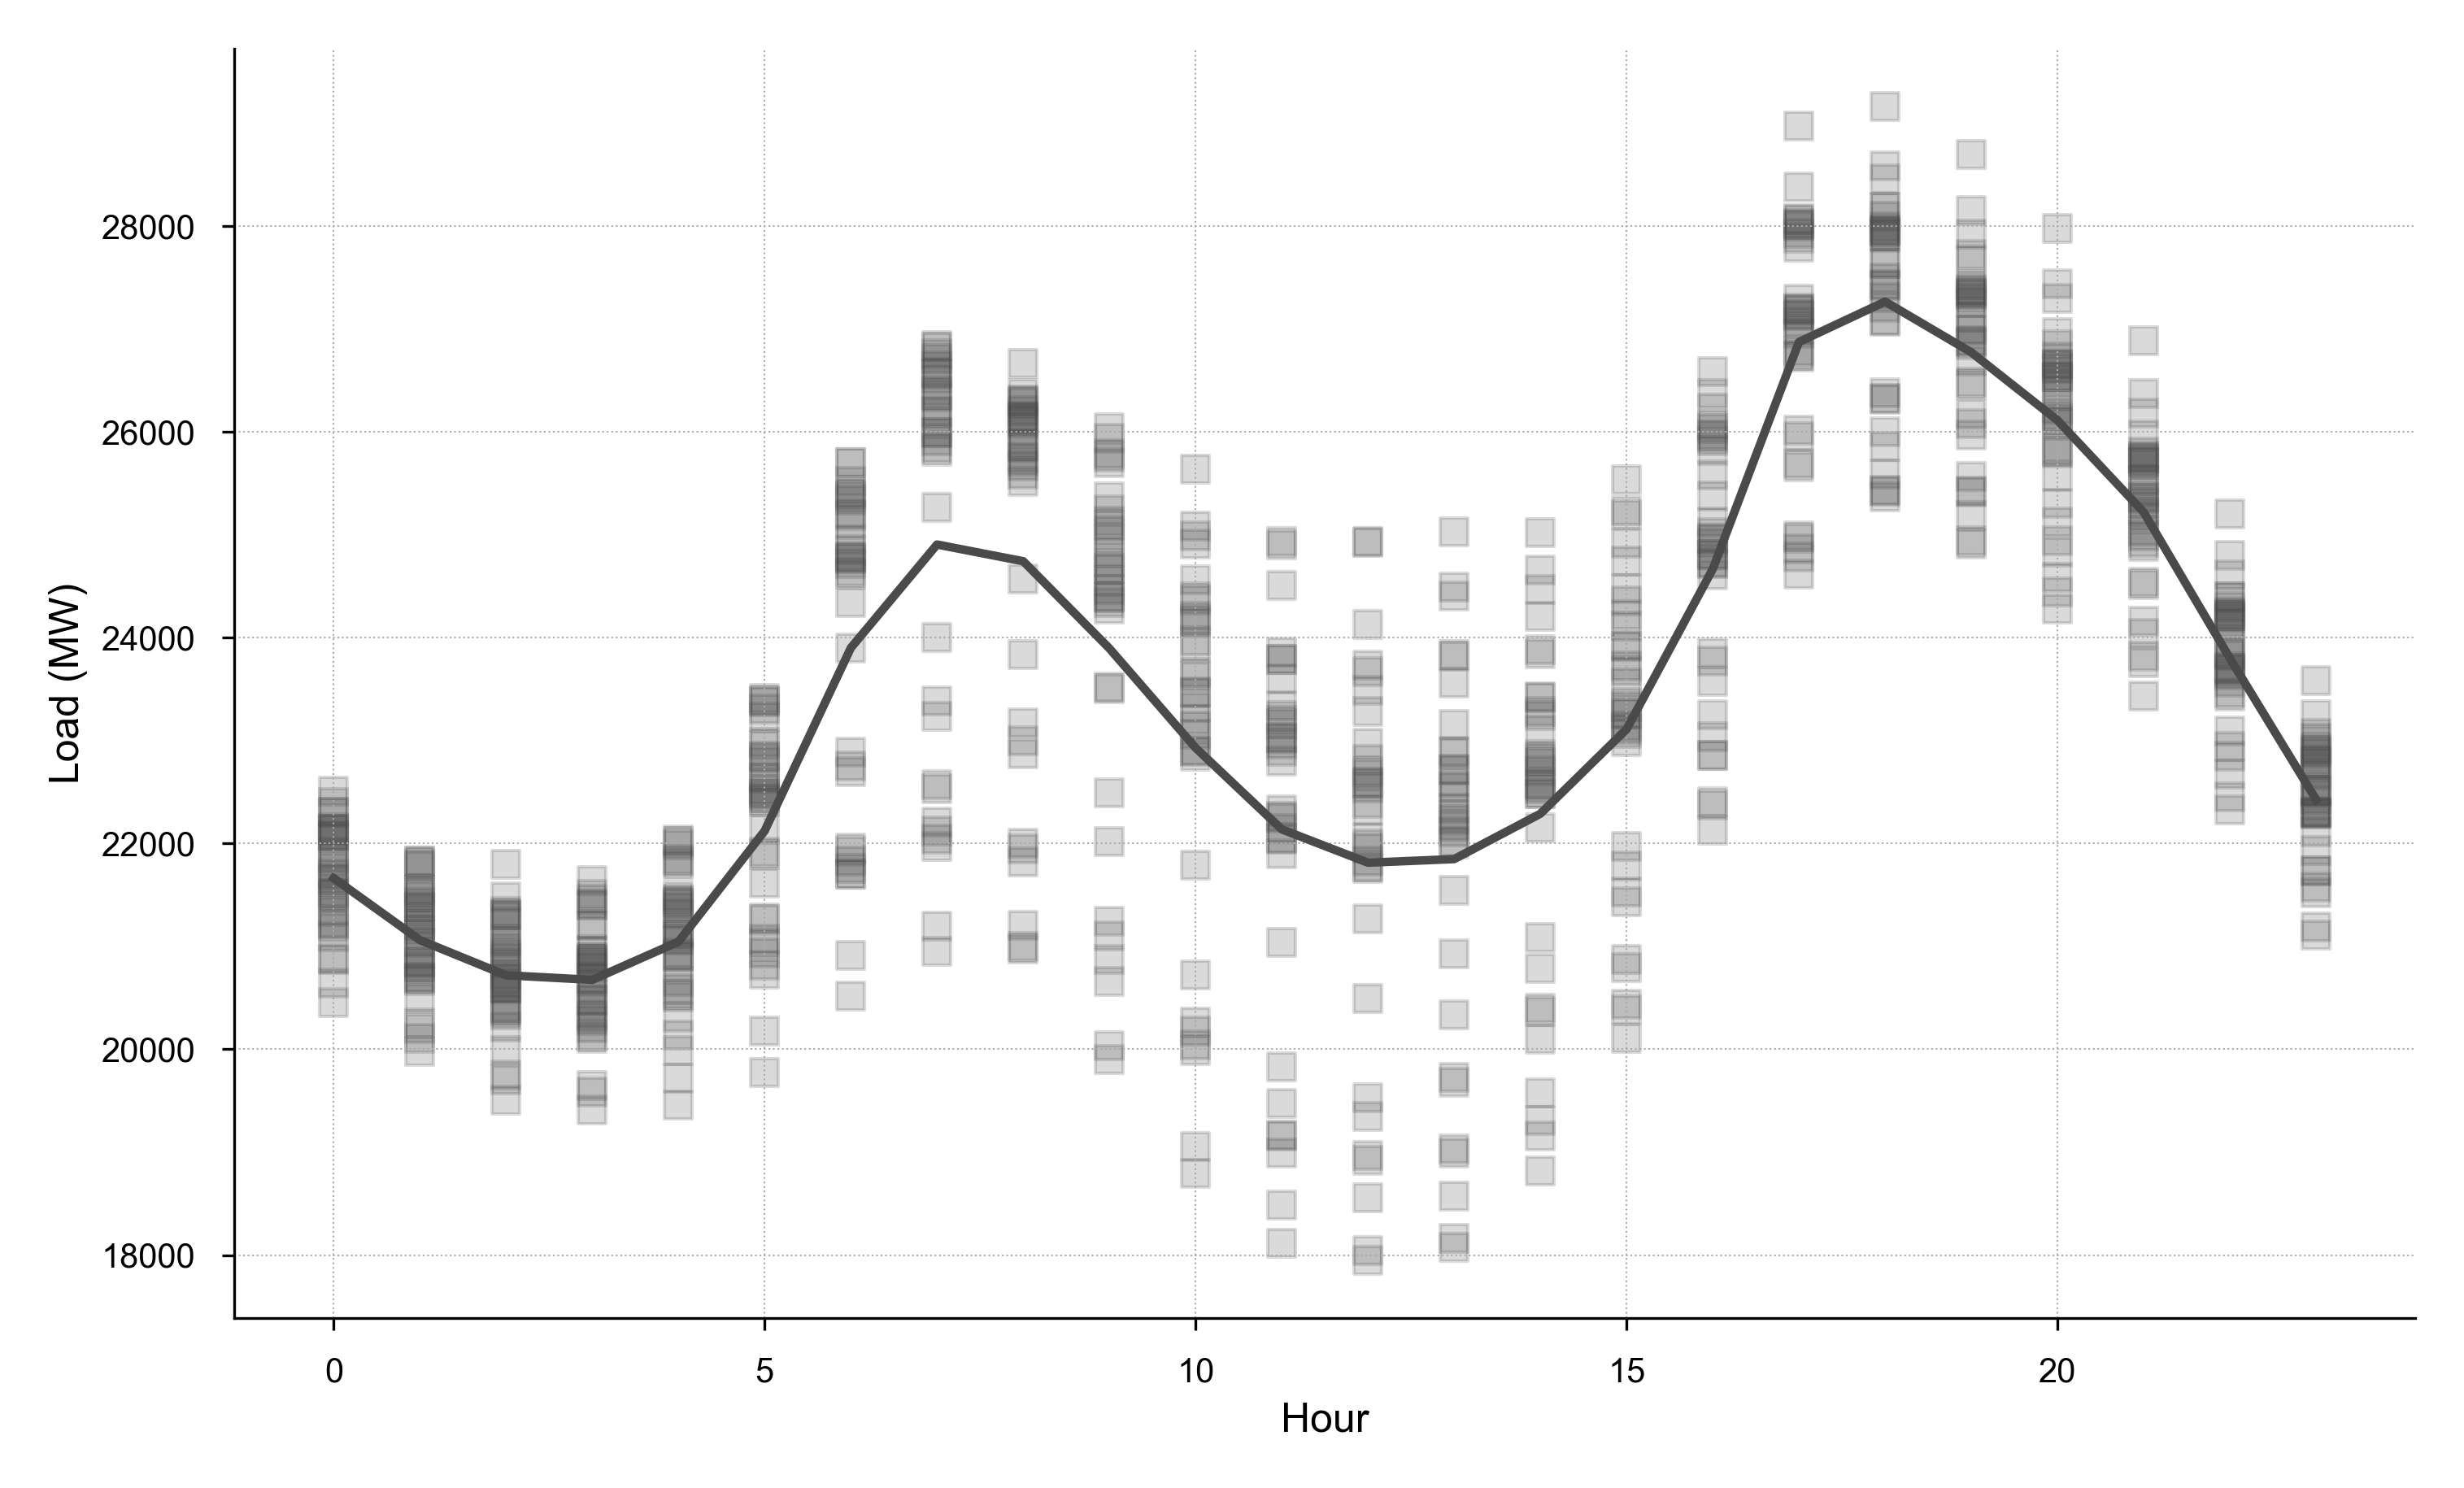

In [27]:
# plot line line chart
plt.figure(figsize=(10, 6))

plt.scatter(df_2022_jan["hour"], df_2022_jan["CAISO"], alpha=0.2, marker="s")
plt.plot(df_2022_month_avg[df_2022_month_avg["month"] == 1]["hour"], df_2022_month_avg[df_2022_month_avg["month"] == 1]["CAISO"], label="Mean")


# plt.title("Hourly Load Demand")
plt.xlabel("Hour")
plt.ylabel("Load (MW)")

plt.show()

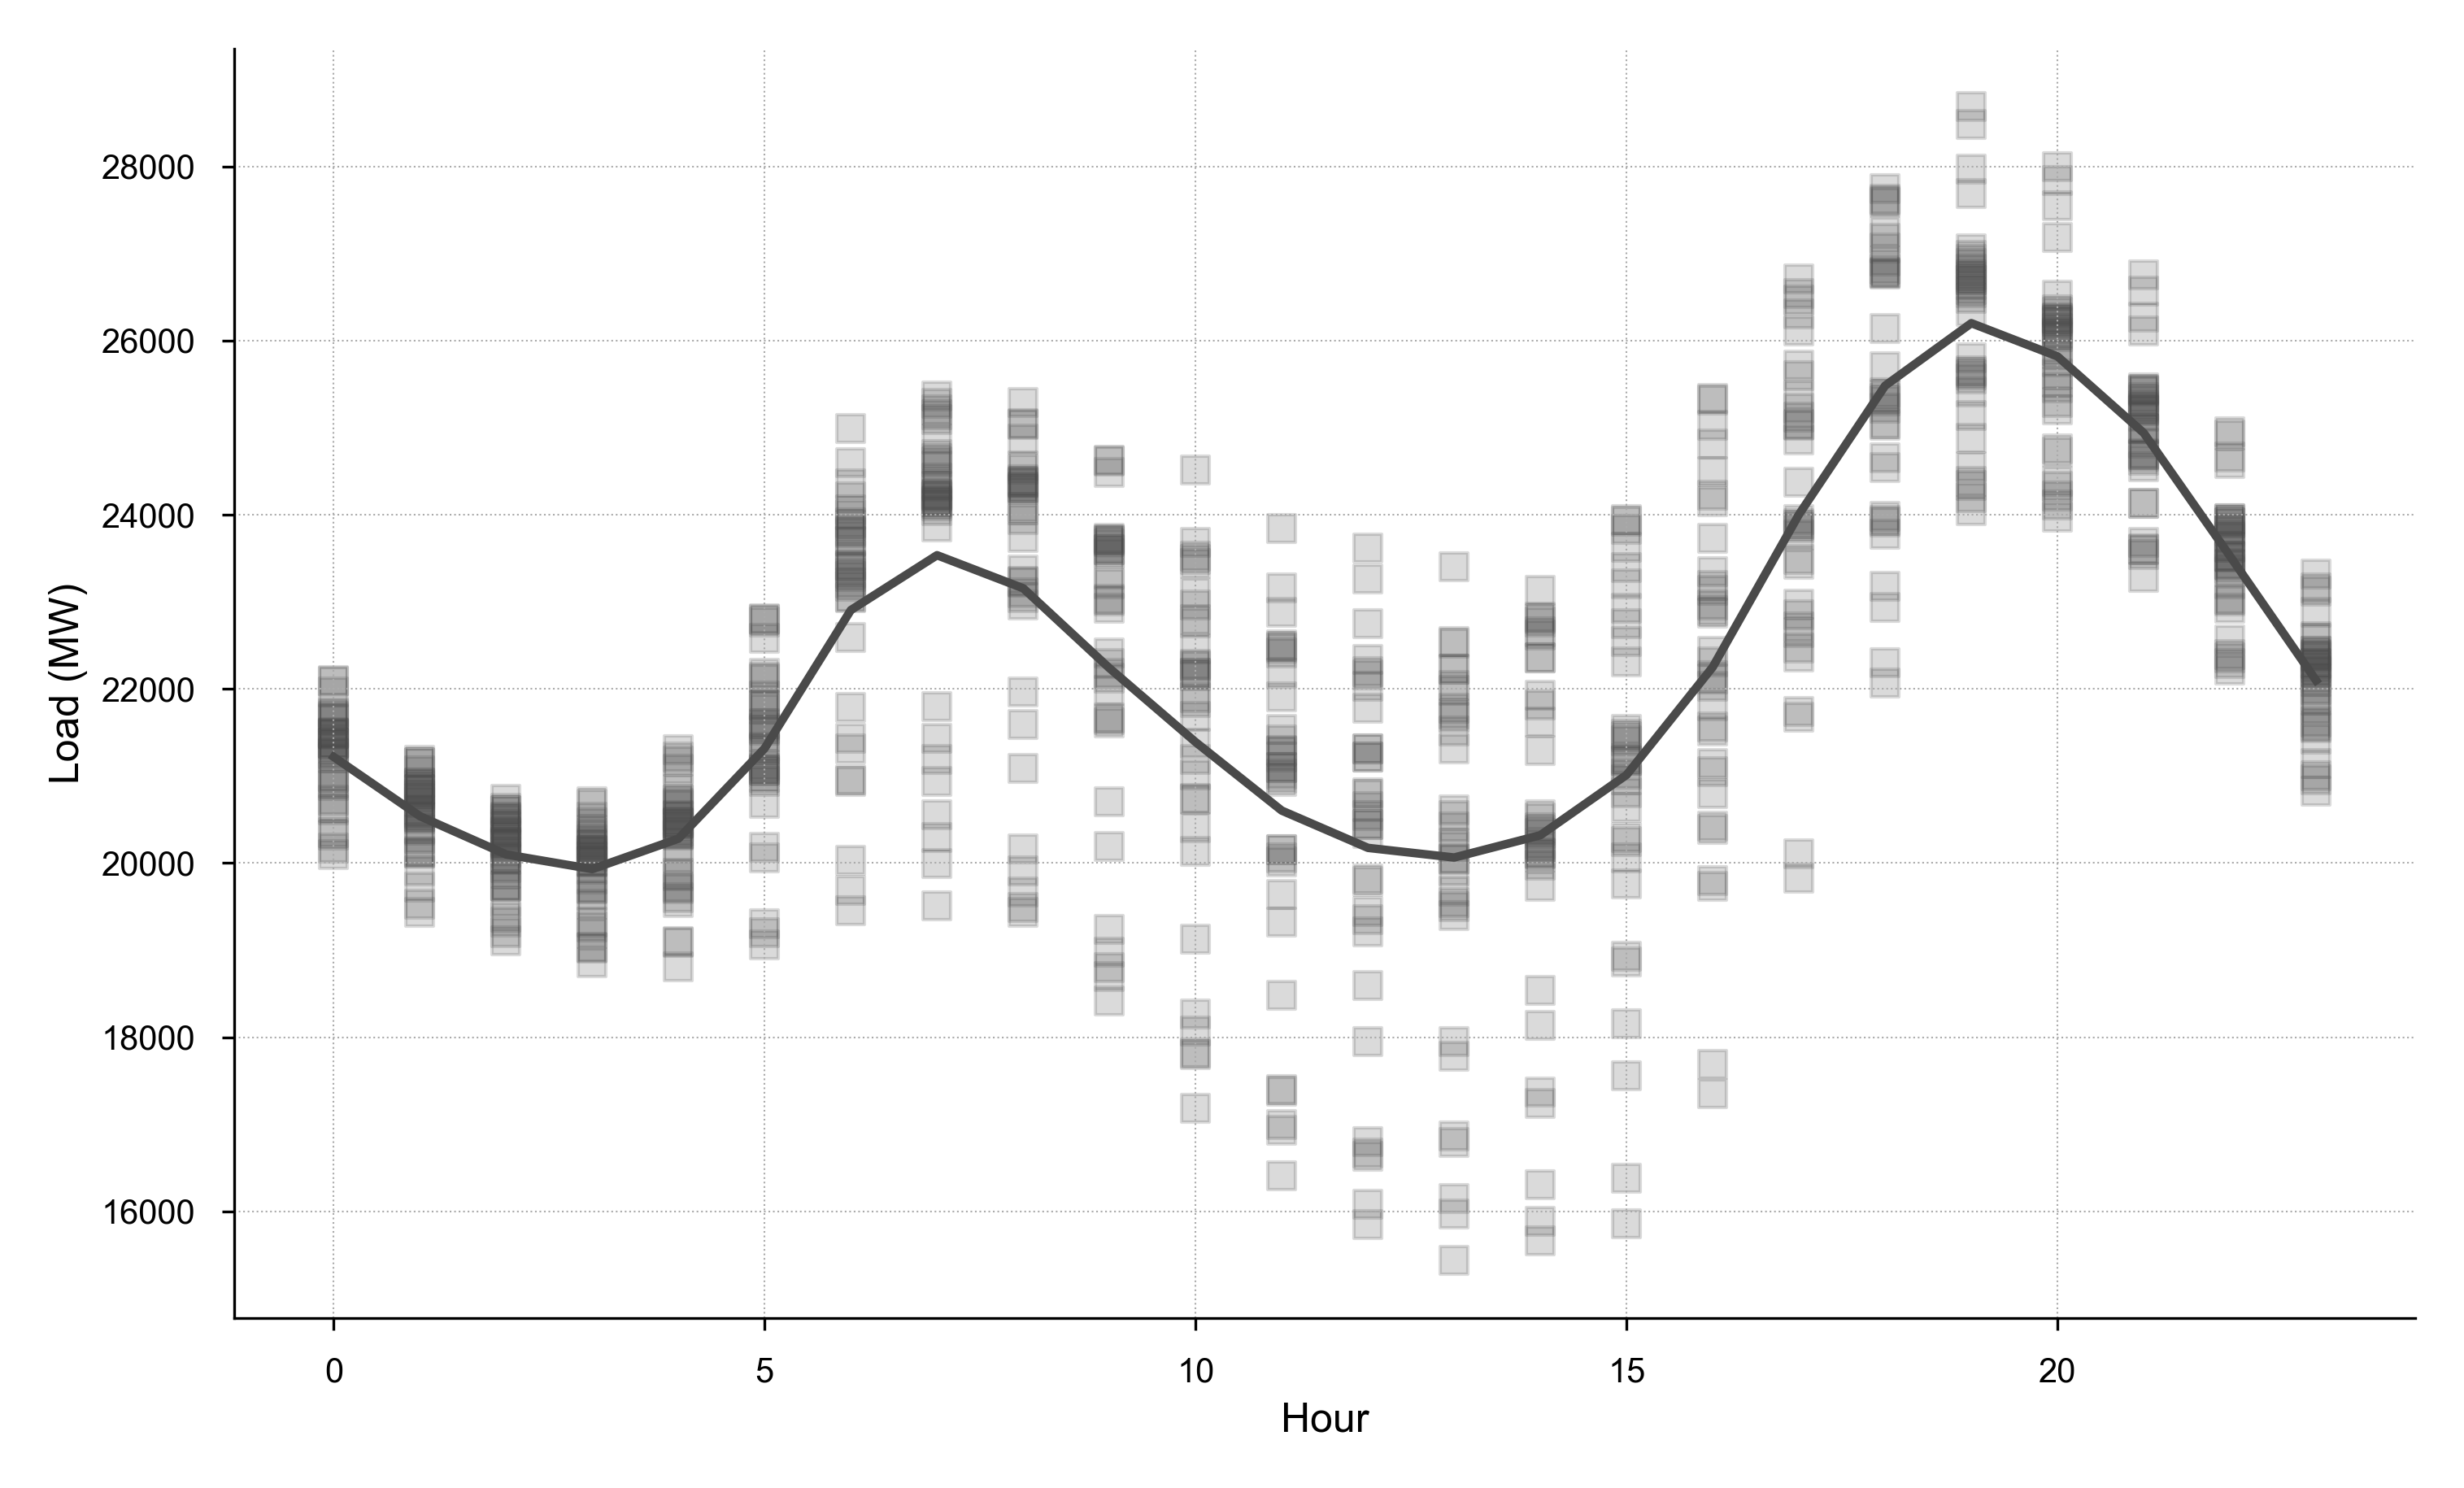

In [28]:
plt.figure(figsize=(10, 6))

plt.scatter(df_2022_march["hour"], df_2022_march["CAISO"], alpha=0.2, marker="s")
plt.plot(df_2022_month_avg[df_2022_month_avg["month"] == 3]["hour"], df_2022_month_avg[df_2022_month_avg["month"] == 3]["CAISO"], label="Mean")
# plt.title("Hourly Load Demand")
plt.xlabel("Hour")
plt.ylabel("Load (MW)")

plt.show()

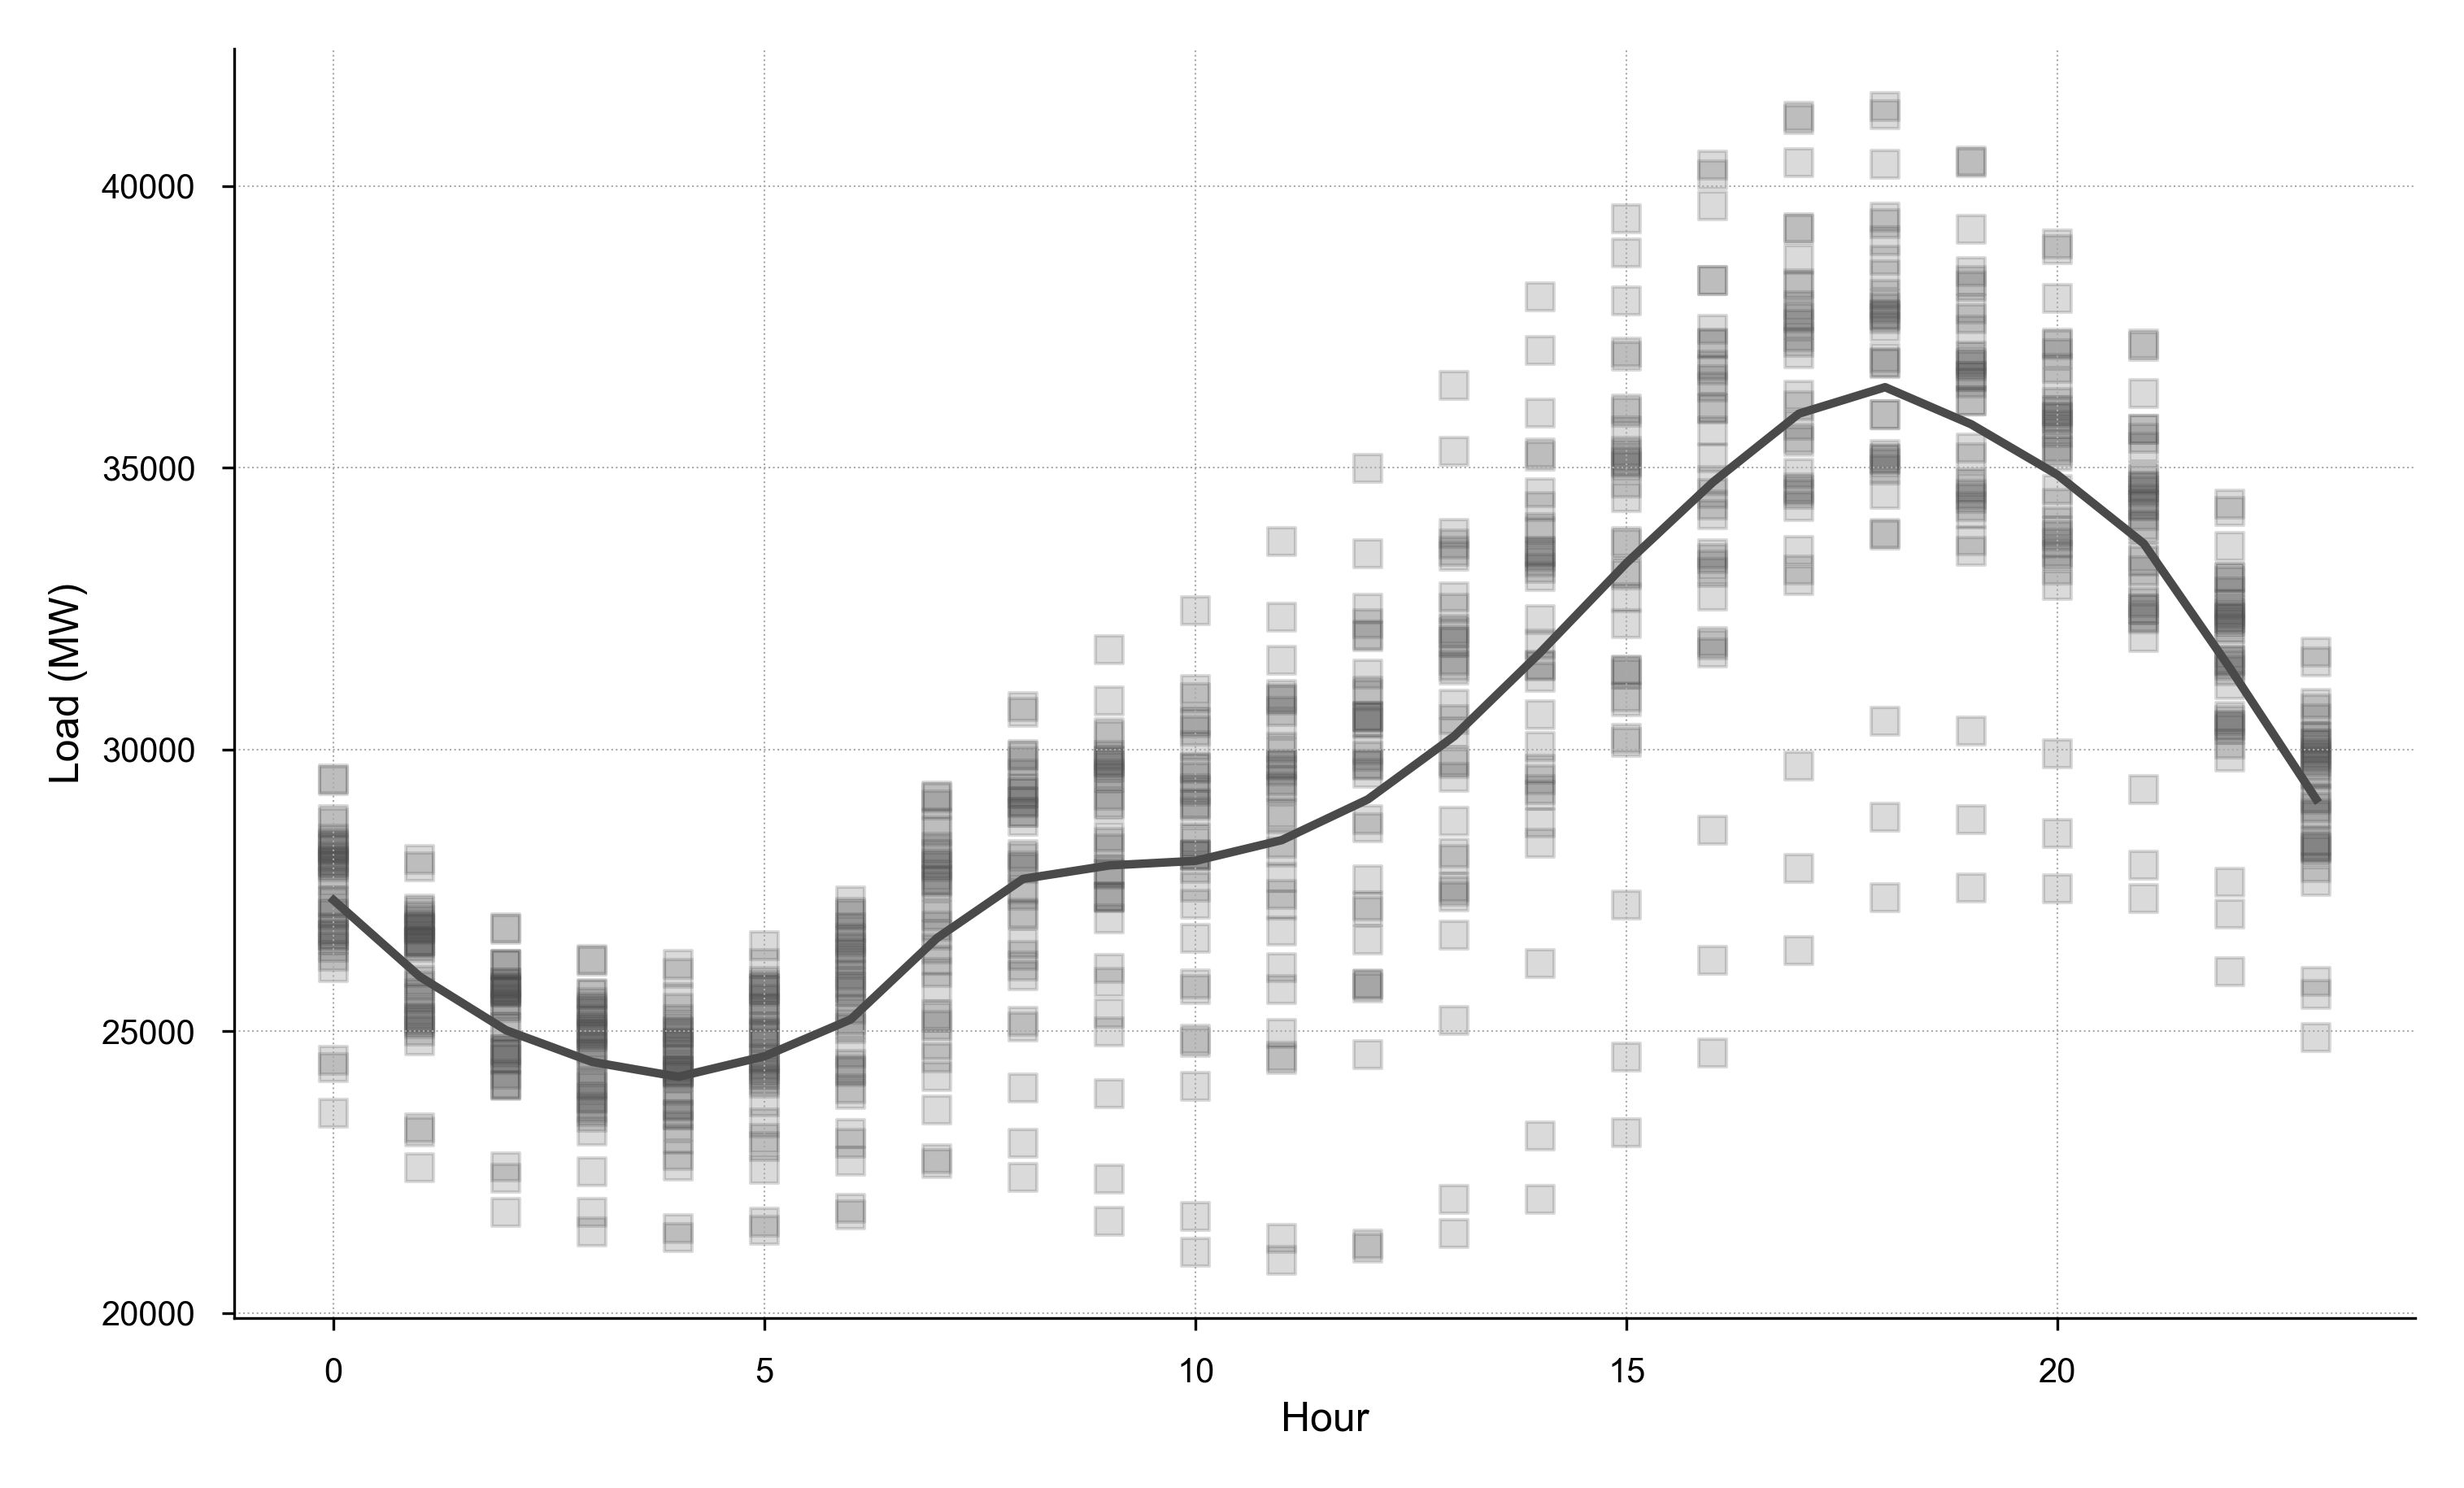

In [29]:
plt.figure(figsize=(10, 6))

plt.scatter(df_2022_july["hour"], df_2022_july["CAISO"], alpha=0.2, marker="s")
plt.plot(df_2022_month_avg[df_2022_month_avg["month"] == 7]["hour"], df_2022_month_avg[df_2022_month_avg["month"] == 7]["CAISO"], label="Mean")
# plt.title("Hourly Load Demand")
plt.xlabel("Hour")
plt.ylabel("Load (MW)")

plt.show()

In [30]:
# # plot histogram
# plt.figure(figsize=(8, 6))
# plt.hist(df[df["HR"] == 3]["CAISO"], bins=50, alpha=0.7)
# plt.show()

# plt.figure(figsize=(8, 6))
# plt.hist(df[df["HR"] == 15]["CAISO"], bins=50, alpha=0.7)
# plt.show()